# From Red Flags to Detection Rules
## An LLM-driven Pipeline for Real-Time GOOSE Intrusion Detection and Prevention

> **Autores:** Lucas A. Martins¹*, Camilla B. Quincozes², Silvio E. Quincozes¹², Marcelo Luizelle², Giovanni Siervo  
> ¹ Universidade Federal de Uberlândia (UFU) – Uberlândia, Brasil  
> ² Universidade Federal do Pampa (UNIPAMPA) – Alegrete, Brasil  
> `{lucas.martins, sequincozes}@ufu.br`

---

### Resumo

Sistemas de Detecção de Intrusão (IDS) baseados em especificação são amplamente utilizados em subestações IEC 61850, mas dependem de regras criadas manualmente por especialistas. Este notebook apresenta um **pipeline orientado por LLM** que automatiza a geração de regras de detecção para detecção e prevenção de intrusões GOOSE em tempo real.

A abordagem utiliza amostras de comunicação rotuladas para identificar *red flags*, que são transformadas em regras de detecção de intrusão executáveis. A prova de conceito usa o **dataset ERENO** e demonstra que as regras geradas detectam comportamentos anômalos com baixo overhead operacional.

## Índice

1. [Introdução](#1-introdução)
2. [IDS Baseado em Especificação para GOOSE](#2-ids-baseado-em-especificação-para-goose)
3. [Arquitetura Proposta](#3-arquitetura-proposta)
4. [Instalação e Configuração do Ambiente](#4-instalação-e-configuração-do-ambiente)
5. [Ingestão de Dados (ERENO)](#5-ingestão-de-dados-ereno)
6. [Extração de Red Flags e Criação de Regras](#6-extração-de-red-flags-e-criação-de-regras)
   - 6.1 [Extração de Red Flags](#61-extração-de-red-flags)
   - 6.2 [Geração de Regras de Detecção](#62-geração-de-regras-de-detecção)
7. [Execução das Regras (rules.py) e registro de resultados](#7-execução-das-regras-rulespy-e-registro-de-resultados)
8. [Geração de Matriz](#8-geração-de-matriz)
   - 8.1 [Pipeline simplificado de avaliação de regras (linear)](#81-pipeline-simplificado-de-avaliação-de-regras-linear)
   - 8.2 [Pipeline completo de avaliação de regras (estruturado)](#82-pipeline-completo-de-avaliação-de-regras-estruturado)
   - 8.3 [Geração de Matriz Visual](#83-geração-de-matriz-visual)
9. [Considerações Finais](#9-considerações-finais)
10. [Referências](#10-referências)

---
## 1. Introdução

Subestações digitais baseadas no padrão **IEC–61850** enfrentam desafios crescentes de cibersegurança, incluindo ataques de:

- **Denial-of-Service (DoS)**
- **Injeção de mensagens (Message Injection)**
- **Mascaramento (Masquerade attacks)**

IDS baseados em especificação são atraentes nesse contexto por seu **baixo overhead computacional** e **interpretabilidade**. No entanto, dependem de regras escritas manualmente por especialistas — processo custoso, difícil de escalar e pouco adaptável.

**Motivação principal:** Automatizar a geração dessas regras usando LLMs a partir de amostras rotuladas do dataset ERENO–IEC–61850.

---
## 2. IDS Baseado em Especificação para GOOSE

O protocolo **GOOSE (Generic Object Oriented Substation Event)**, definido pelo padrão IEC–61850-8-1, suporta operações de proteção e controle em tempo crítico via modelo publisher/subscriber sobre Ethernet.

### Campos relevantes de um frame GOOSE

| Categoria | Campos |
|-----------|--------|
| Estruturais | `dst_mac`, `TPID`, `ethType`, `gooseAppid`, `timeAllowedToLive` |
| Consistência | `gocbRef`, `datSet`, `goID`, `t`, `stNum`, `sqNum` |
| Dinâmica | frequência de mensagens, bytes/s, pacotes/s |

> ⚠️ O GOOSE não foi projetado com mecanismos nativos de segurança robustos, tornando-o vulnerável a ataques de injeção, replay e negação de serviço.

---
## 3. Arquitetura Proposta

O pipeline é composto por **quatro estágios principais**:

```
┌─────────────────┐     ┌──────────────────┐     ┌───────────────────┐     ┌──────────────────┐
│  Dataset GOOSE  │───▶│ Red Flag Extract.│───▶│  Rule Generation  │───▶│ Switch Simulation│
│  Rotulado       │     │ (LLM-based)      │     │  (Python rules)   │     │  (Real-time)     │
│  (ERENO)        │     │                  │     │                   │     │                  │
└─────────────────┘     └──────────────────┘     └───────────────────┘     └──────────────────┘
```

| Estágio | Responsabilidade |
|---------|------------------|
| **1. Source Ingestion** | Carrega dataset, organiza features, prepara prompts estruturados |
| **2. Red Flag Extraction** | LLM identifica padrões suspeitos e inconsistências comportamentais |
| **3. Rule Generation** | Traduz red flags em regras Python executáveis |
| **4. Simulated Deployment** | Executa regras sobre tráfego GOOSE em tempo real simulado |

---
## 4. Instalação e Configuração do Ambiente

In [1]:
# Instalação das dependências (recomenda-se ambiente virtual)
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd

from groq import Groq
from dotenv import load_dotenv

load_dotenv()  # carrega variáveis do .env na sessão

api_key = os.getenv("GROQ_API_KEY")

if not api_key:
    raise RuntimeError("Defina GROQ_API_KEY no arquivo .env.")

groq_client = Groq(api_key=api_key)
engine_model = "openai/gpt-oss-120b" #openai/gpt-oss-120b"


def get_groq_client():
    return groq_client

# Mensagem de sucesso
print(" Célula executada com sucesso!")
print(f" API Key carregada: {'*' * 20}{api_key[-4:]}")
print(f" Modelo configurado: {engine_model}")
print(f" Cliente Groq inicializado com sucesso!")

 Célula executada com sucesso!
 API Key carregada: ********************Ykfy
 Modelo configurado: openai/gpt-oss-120b
 Cliente Groq inicializado com sucesso!


---
## 5. Ingestão de Dados (ERENO)

O dataset **ERENO–IEC–61850** fornece amostras rotuladas de tráfego GOOSE em condições normais e sob ataque.

Cada amostra contém features de três tipos:
- **Protocol-level:** campos do protocolo GOOSE
- **Temporal:** diferenças de timestamp entre mensagens
- **Derived:** métricas calculadas como `stDiff`, `sqDiff`, `timestampDiff`

In [5]:
from pathlib import Path
import pandas as pd

# ============================================================================
# FUNÇÃO PARA SOLICITAR ARQUIVO CSV AO USUÁRIO (COM VALIDAÇÃO)
# ============================================================================

def get_csv_path_from_user() -> Path:
    """
    Solicita ao usuário o caminho do arquivo CSV a ser utilizado.
    Procura automaticamente por arquivos CSV no diretório atual.
    """
    print("\n" + "=" * 60)
    print(" SELEÇÃO DA BASE DE DADOS CSV")
    print("=" * 60)
    
    # Procura por arquivos CSV no diretório atual e subdiretórios
    csv_files = []
    
    # Busca no diretório atual
    csv_files.extend(sorted(Path(".").glob("*.csv")))
    
    # Busca em subdiretórios comuns
    for search_dir in ["small_dataset", "dataset", "data", "datasets", "input", "train"]:
        if Path(search_dir).exists():
            csv_files.extend(sorted(Path(search_dir).glob("*.csv")))
    
    # Filtra apenas CSVs que não estão em pastas de backup (old_data, old_rules)
    csv_files = [f for f in csv_files if "old_data" not in str(f) and "old_rules" not in str(f)]
    
    if csv_files:
        print(f"\n {len(csv_files)} arquivo(s) CSV encontrado(s):")
        for i, csv_file in enumerate(csv_files, 1):
            try:
                size_mb = csv_file.stat().st_size / (1024 * 1024)
                # Tenta ler a primeira linha para verificar se tem as colunas esperadas
                try:
                    test_df = pd.read_csv(csv_file, nrows=1)
                    has_columns = any(col in test_df.columns for col in ["StNum", "SqNum", "class"])
                    status = "✓" if has_columns else "⚠️  (pode não ter as colunas necessárias)"
                except:
                    status = "⚠️  (erro na leitura)"
                print(f"  {i}. {csv_file} ({size_mb:.2f} MB) {status}")
            except:
                print(f"  {i}. {csv_file}")
        
        print(f"\n Opções:")
        print(f"  - Digite o número do arquivo (1-{len(csv_files)})")
        print(f"  - Digite o caminho completo de outro arquivo")
        print(f"  - Pressione Enter para usar a opção 1")
        
        user_input = input("\n Sua escolha: ").strip()
        
        if not user_input:
            selected = csv_files[0]
            print(f" Arquivo selecionado: {selected}")
            return selected
        
        try:
            index = int(user_input) - 1
            if 0 <= index < len(csv_files):
                selected = csv_files[index]
                print(f" Arquivo selecionado: {selected}")
                return selected
            else:
                print(f" Número fora do intervalo (1-{len(csv_files)}). Usando opção 1.")
                return csv_files[0]
        except ValueError:
            path = Path(user_input)
            if path.exists() and path.suffix.lower() == '.csv':
                print(f" Arquivo selecionado: {path}")
                return path
            else:
                print(f" Arquivo '{user_input}' não encontrado ou não é CSV!")
                print(f" Usando o primeiro arquivo disponível: {csv_files[0]}")
                return csv_files[0]
    
    else:
        print(f"\n Nenhum arquivo CSV válido encontrado automaticamente!")
        print(f"\n Digite o caminho completo do arquivo CSV:")
        print(f"  Exemplo: small_dataset/train.csv")
        print(f"  Exemplo: /home/user/dados/dataset.csv")
        
        while True:
            user_input = input("\n Caminho do arquivo CSV: ").strip()
            
            if not user_input:
                print(" Caminho não pode ser vazio!")
                continue
            
            path = Path(user_input)
            if path.exists():
                if path.suffix.lower() == '.csv':
                    print(f" Arquivo selecionado: {path}")
                    return path
                else:
                    print(f" O arquivo não tem extensão .csv. Deseja usar mesmo assim? (s/n): ")
                    if input().strip().lower() == 's':
                        print(f" Arquivo selecionado: {path}")
                        return path
            else:
                print(f" Arquivo '{user_input}' não encontrado!")

# ============================================================================
# FUNÇÃO PARA VALIDAR O DATASET
# ============================================================================

def validate_dataset(df: pd.DataFrame) -> bool:
    """
    Valida se o dataset tem as colunas mínimas necessárias.
    """
    required_cols = ["StNum", "SqNum", "class"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    
    if missing_cols:
        print(f"\n❌ ERRO: Dataset inválido! Colunas obrigatórias não encontradas:")
        for col in missing_cols:
            print(f"   - {col}")
        print(f"\n📋 Colunas encontradas no CSV: {list(df.columns)}")
        print(f"\n💡 Dica: Use o arquivo 'small_dataset/train.csv' que tem o formato correto.")
        return False
    
    return True

# ============================================================================
# CARREGAMENTO DO DATASET COM SELEÇÃO DO USUÁRIO
# ============================================================================

# Solicita ao usuário o caminho do arquivo CSV
DATASET_PATH = get_csv_path_from_user()

print(f"\n📖 Carregando CSV: {DATASET_PATH}")

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset não encontrado em {DATASET_PATH.resolve()}")

df = pd.read_csv(DATASET_PATH)

print(f"Dataset carregado: {len(df)} amostras, {df.shape[1]} features\n")

# VALIDA O DATASET
if not validate_dataset(df):
    print("\n" + "=" * 60)
    print(" TENTANDO CARREGAR O DATASET PADRÃO (small_dataset/train.csv)")
    print("=" * 60)
    
    default_path = Path("small_dataset/train.csv")
    if default_path.exists():
        print(f"📖 Carregando dataset padrão: {default_path}")
        df = pd.read_csv(default_path)
        print(f"Dataset carregado: {len(df)} amostras, {df.shape[1]} features\n")
        
        if not validate_dataset(df):
            raise ValueError("Dataset padrão também é inválido! Verifique o arquivo.")
    else:
        raise FileNotFoundError("Dataset padrão não encontrado! Verifique o arquivo small_dataset/train.csv")

# 1) Garante que TODAS as colunas importantes + 'class' sejam consideradas
IMPORTANT_COLUMNS = [
    "SqNum",
    "StNum",
    "cbStatus",
    "goID",
    "stDiff",
    "sqDiff",
    "gooseLengthDiff",
    "cbStatusDiff",
    "apduSizeDiff",
    "frameLengthDiff",
    "timestampDiff",
    "tDiff",
    "timeFromLastChange",
    "delay",
    "class"
]

# 2) Garante que só usa colunas que existem de fato no df
available_cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
missing_cols = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

print("\n📋 Colunas usadas no prompt:")
for c in available_cols:
    print(" -", c)

if missing_cols:
    print("\n[Aviso] Colunas não encontradas no dataset e ignoradas:")
    for c in missing_cols:
        print(" -", c)

# 3) Cria df_reduced COM APENAS essas colunas (todo o resto é removido)
df_reduced = df[available_cols].copy()
print(f"\n📊 Dataset reduzido: {len(df_reduced)} amostras, {df_reduced.shape[1]} features")

# 4) Confirmar que só sobraram colunas importantes + class:
print("\n📋 Colunas finais em df_reduced:")
for col in df_reduced.columns:
    print(" -", col)

# 5) Mostra primeiras linhas
print("\n📊 Primeiras linhas:")
display(df_reduced.head())

# 6) Mostra distribuição das classes
print("\n📊 Distribuição das classes:")
class_counts = df_reduced["class"].value_counts()
for cls, count in class_counts.items():
    print(f"  {cls}: {count} amostras")


 SELEÇÃO DA BASE DE DADOS CSV

 11 arquivo(s) CSV encontrado(s):
  1. confusion_matrix.csv (0.00 MB) ✓
  2. confusion_matrix_train.csv (0.00 MB) ✓
  3. deteccoes_agregado_classes.csv (0.00 MB) ⚠️  (pode não ter as colunas necessárias)
  4. deteccoes_por_amostra.csv (6.89 MB) ⚠️  (pode não ter as colunas necessárias)
  5. detection_results.csv (63.40 MB) ✓
  6. detection_results_train.csv (0.06 MB) ✓
  7. latencia_regras.csv (0.00 MB) ⚠️  (pode não ter as colunas necessárias)
  8. matriz_regras_ataques.csv (0.00 MB) ⚠️  (pode não ter as colunas necessárias)
  9. small_dataset/ERENO-2.0-100K.csv (119.18 MB) ✓
  10. small_dataset/test.csv (0.48 MB) ✓
  11. small_dataset/train.csv (0.13 MB) ✓

 Opções:
  - Digite o número do arquivo (1-11)
  - Digite o caminho completo de outro arquivo
  - Pressione Enter para usar a opção 1



 Sua escolha:  9


 Arquivo selecionado: small_dataset/ERENO-2.0-100K.csv

📖 Carregando CSV: small_dataset/ERENO-2.0-100K.csv
Dataset carregado: 200052 amostras, 52 features


📋 Colunas usadas no prompt:
 - SqNum
 - StNum
 - cbStatus
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - timestampDiff
 - tDiff
 - timeFromLastChange
 - delay
 - class

📊 Dataset reduzido: 200052 amostras, 15 features

📋 Colunas finais em df_reduced:
 - SqNum
 - StNum
 - cbStatus
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - timestampDiff
 - tDiff
 - timeFromLastChange
 - delay
 - class

📊 Primeiras linhas:


/tmp/ipykernel_20676/781162239.py:137: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


,SqNum,StNum,cbStatus,goID,stDiff,sqDiff,gooseLengthDiff,cbStatusDiff,apduSizeDiff,frameLengthDiff,timestampDiff,tDiff,timeFromLastChange,delay,class
0,1.0,1.0,0.0,IntLockA,0.0,0.0,0.0,0.0,0.0,0.0,0.005068,0.000000,0.022390,0.000130,grayhole
1,1.0,1.0,0.0,IntLockA,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.022390,0.000130,normal
2,87.0,35.0,2.0,IntLockA,34.0,86.0,0.0,1.0,0.0,0.0,0.335783,97.634223,-97.276050,0.000123,injection
3,20.0,84309.0,0.0,IntLockA,84274.0,-67.0,0.0,1.0,0.0,0.0,0.128662,6302.515166,-6399.662553,0.000055,high_StNum
4,62.0,26886.0,0.0,IntLockA,-57423.0,42.0,0.0,0.0,0.0,0.0,0.256906,519.062125,-6918.467772,0.000131,high_StNum



📊 Distribuição das classes:
  normal: 39999 amostras
  masquerade_fake_normal: 20000 amostras
  injection: 20000 amostras
  high_StNum: 20000 amostras
  random_replay: 20000 amostras
  masquerade_fake_fault: 20000 amostras
  inverse_replay: 20000 amostras
  poisoned_high_rate: 20000 amostras
  grayhole: 19999 amostras


---
## 6. Extração bruta de Red Flags e Criação de Regras sem refinamento

---
### 6.1 Extração bruta de Red Flags 

In [6]:
import time
import json
from pathlib import Path
from datetime import datetime
import requests

import pandas as pd
import numpy as np


# ─── Função para backup de red_flags.json ─────────────────────────────────────

def backup_current_red_flags():
    """
    Faz backup do arquivo red_flags.json recém-criado para a pasta old_rules/
    com timestamp no nome do arquivo.
    """
    current_file = Path("red_flags.json")
    
    if current_file.exists():
        # Cria a pasta old_rules se não existir
        backup_dir = Path("old_rules")
        backup_dir.mkdir(exist_ok=True)
        
        # Gera nome com timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        backup_file = backup_dir / f"red_flags_{timestamp}.json"
        
        # Copia o arquivo recém-criado para o backup
        backup_file.write_text(
            current_file.read_text(encoding="utf-8"),
            encoding="utf-8"
        )
        
        print(f" Backup criado na pasta old_rules: {backup_file.name}")
        return backup_file
    else:
        print(" Arquivo red_flags.json não encontrado para backup")
        return None


# ─── FUNÇÃO PARA NORMALIZAR A COLUNA CLASS ────────────────────────────────────

def normalize_class_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normaliza a coluna 'class' para string, tratando valores nulos e inconsistentes.
    """
    if "class" not in df.columns:
        return df
    
    # Converte para string, tratando NaN e None
    df = df.copy()
    df["class"] = df["class"].astype(str)
    
    # Remove valores problemáticos
    df = df[~df["class"].isin(["nan", "None", "", "NaN", "null", "nan", "None", "NaN"])]
    
    # Remove linhas com valores nulos
    df = df.dropna(subset=["class"])
    
    return df


# ─── 1. Seleção de amostras (CORRIGIDA) ───────────────────────────────────────

def sample_normal_and_attacks(
    df: pd.DataFrame,
    n_normal: int = 15,
    n_per_attack: int = 8,
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """
    Separa amostras de referência normal e amostras por classe de ataque.
    CORRIGIDA: Normaliza a coluna class antes de processar.
    """
    # Normaliza a coluna class
    df = normalize_class_column(df)
    
    # Verifica se há amostras normais
    normal_count = (df["class"] == "normal").sum()
    if normal_count == 0:
        print("  [AVISO] Nenhuma amostra 'normal' encontrada no dataset!")
        print("  Criando DataFrame normal vazio...")
        df_normal = pd.DataFrame()
    else:
        df_normal = df[df["class"] == "normal"].sample(
            n=min(n_normal, normal_count),
            random_state=42,
        )
    
    # Obtém classes de ataque (todas exceto 'normal')
    attack_classes = sorted([c for c in df["class"].unique() if c != "normal"])
    attack_samples: dict[str, pd.DataFrame] = {}

    for cls in attack_classes:
        df_cls = df[df["class"] == cls]
        n_samples = min(n_per_attack, len(df_cls))
        if n_samples > 0:
            attack_samples[cls] = df_cls.sample(
                n=n_samples,
                random_state=42,
            )
        else:
            print(f"  [AVISO] Classe '{cls}' não tem amostras suficientes")

    return df_normal, attack_samples


# ─── 2. Prompt para red flags (VERSÃO CORRIGIDA) ─────────────────────────────

def make_red_flags_prompt(
    df_normal: pd.DataFrame,
    df_attack: pd.DataFrame,
    attack_class: str,
    normal_stats: dict = None,
) -> str:
    """
    Cria um prompt para red flags com estatísticas completas do tráfego normal
    (média, desvio padrão, percentis) para ajudar o LLM a criar condições
    discriminativas que não disparem em tráfego legítimo.
    """
    if df_normal.empty:
        prompt = f"""Analyze GOOSE traffic for IEC 61850 substation.

WARNING: No normal traffic samples available for comparison.

ATTACK class '{attack_class}' samples — identify RED FLAGS vs. expected IEC 61850 behavior.

Format each red flag as:
- RED FLAG: [name]
  FIELDS: [fields]
  REASON: [why anomalous per IEC 61850]

Focus on StNum, SqNum, stDiff, sqDiff patterns."""
        return prompt

    numeric_cols = [c for c in [
        "SqNum","StNum","stDiff","sqDiff","cbStatus","cbStatusDiff",
        "gooseLengthDiff","apduSizeDiff","tDiff","timestampDiff",
        "timeFromLastChange","delay"
    ] if c in df_normal.columns]

    # Estatísticas ricas do normal: média ± std + percentis chave
    normal_profile = {}
    for col in numeric_cols:
        vals = df_normal[col].dropna()
        if len(vals) > 0:
            normal_profile[col] = {
                "mean":  round(float(vals.mean()), 4),
                "std":   round(float(vals.std()), 4),
                "p5":    round(float(vals.quantile(0.05)), 4),
                "p95":   round(float(vals.quantile(0.95)), 4),
                "min":   round(float(vals.min()), 4),
                "max":   round(float(vals.max()), 4),
            }

    attack_profile = {}
    for col in numeric_cols:
        if col in df_attack.columns:
            vals = df_attack[col].dropna()
            if len(vals) > 0:
                attack_profile[col] = {
                    "mean": round(float(vals.mean()), 4),
                    "std":  round(float(vals.std()), 4),
                    "min":  round(float(vals.min()), 4),
                    "max":  round(float(vals.max()), 4),
                }

    prompt = f"""Analyze GOOSE traffic for IEC 61850 substation.

NORMAL traffic profile (use this as the discriminative baseline — rules must NOT fire on these ranges):
{json.dumps(normal_profile, indent=2)}

ATTACK class '{attack_class}' profile:
{json.dumps(attack_profile, indent=2)}

Task: List RED FLAGS (behavioral patterns) that distinguish this attack from normal traffic.
Each red flag MUST describe a condition that is OUTSIDE the normal p5–p95 range above.
Avoid flags that are also true in normal traffic (e.g. gooseLengthDiff==0 is normal behavior!).

Format each red flag as:
- RED FLAG: [name]
  FIELDS: [fields]
  REASON: [why anomalous per IEC 61850, referencing the normal profile above]
  THRESHOLD: [specific numeric threshold that separates attack from normal]"""

    return prompt


# ─── 3. Chamada ao LLM usando REQUESTS diretamente ───────────────────────────

def call_llm_for_red_flags_with_retry(
    prompt: str,
    model: str = engine_model,
    max_retries: int = 5,
) -> str:
    """
    Envia o prompt usando requests diretamente (evita bugs do SDK).
    """
    api_key = os.getenv("GROQ_API_KEY")
    if not api_key:
        raise ValueError("GROQ_API_KEY não encontrada no ambiente")
    
    url = "https://api.groq.com/openai/v1/chat/completions"
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }
    
    payload = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0,
        "max_tokens": 2048,
        "top_p": 1,
    }
    
    # Verifica tamanho real da requisição
    payload_size = len(json.dumps(payload).encode('utf-8'))
    print(f"  Tamanho da requisição: {payload_size / 1024:.2f} KB")
    
    if payload_size > 100 * 1024:
        raise ValueError(f"Requisição muito grande: {payload_size/1024:.1f} KB")
    
    attempt = 0
    while attempt < max_retries:
        try:
            response = requests.post(url, headers=headers, json=payload, timeout=60)
            
            if response.status_code == 200:
                result = response.json()
                return result["choices"][0]["message"]["content"].strip()
            elif response.status_code == 429:  # Rate limit
                attempt += 1
                wait = min(60, 2 ** attempt)
                print(f"  Rate limit. Aguardando {wait}s (tentativa {attempt}/{max_retries})...")
                time.sleep(wait)
            else:
                print(f"  Erro HTTP {response.status_code}: {response.text[:200]}")
                attempt += 1
                if attempt >= max_retries:
                    raise Exception(f"HTTP {response.status_code}: {response.text}")
                time.sleep(2 ** attempt)
                
        except requests.exceptions.RequestException as e:
            attempt += 1
            print(f"  Erro de requisição: {e}")
            if attempt >= max_retries:
                raise
            time.sleep(2 ** attempt)
    
    raise Exception("Número máximo de tentativas excedido")


# ─── 4. Pipeline principal ───────────────────────────────────────

print("=== Verificando dataset ===")
print(f"Dataset original: {len(df_reduced)} amostras, {df_reduced.shape[1]} features")

# Normaliza a coluna class ANTES de tudo
df_reduced = normalize_class_column(df_reduced)
print(f"Após normalização: {len(df_reduced)} amostras")

# Mostra classes disponíveis
print(f"Classes únicas: {sorted(df_reduced['class'].unique())}")

print("\n=== Coletando amostras ===")
df_normal_ref, attack_samples = sample_normal_and_attacks(
    df_reduced,
    n_normal=10,
    n_per_attack=5,
)

print(f"Amostra normal: {len(df_normal_ref)} linhas")
print(f"Classes de ataque: {list(attack_samples.keys())}")

red_flags_by_class: dict[str, str] = {}

for attack_class, df_attack in attack_samples.items():
    print(f"\n=== Identificando red flags para classe: {attack_class} ===")
    print(f"  Amostras de ataque: {len(df_attack)} linhas")
    
    prompt_rf = make_red_flags_prompt(df_normal_ref, df_attack, attack_class, normal_stats=None)  # normal_stats calculado na célula 14
    print(f"  Prompt size: {len(prompt_rf)} caracteres")
    
    try:
        red_flags_text = call_llm_for_red_flags_with_retry(
            prompt_rf,
            model=engine_model,
            max_retries=5,
        )
        red_flags_by_class[attack_class] = red_flags_text
        print(f"  [SUCESSO] Red flags geradas")
        print(f"\n{red_flags_text[:500]}...")
        
    except Exception as e:
        print(f"  [ERRO] {e}")
        red_flags_by_class[attack_class] = f"ERRO: {str(e)}"

# Salva as novas red flags (sobrescreve se já existir)
rf_output = Path("red_flags.json")
rf_output.write_text(
    json.dumps(red_flags_by_class, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(f"\n=== NOVAS red flags salvas em: {rf_output.resolve()} ===")

# Faz o backup AGORA, depois que o arquivo foi escrito/sobrescrito
print("\n=== CRIANDO BACKUP DO ARQUIVO GERADO ===")
backup_file = backup_current_red_flags()
if backup_file:
    print(f" Backup concluído com sucesso!")

print("\n=== RESUMO ===")
for cls, flags in red_flags_by_class.items():
    if not flags.startswith("ERRO"):
        print(f"✓ {cls}: OK")
    else:
        print(f"✗ {cls}: FALHA")

# Lista todos os backups existentes
print(f"\n=== HISTÓRICO DE BACKUPS (pasta old_rules) ===")
backup_dir = Path("old_rules")
if backup_dir.exists():
    backups = sorted(backup_dir.glob("red_flags_*.json"))
    if backups:
        for i, backup in enumerate(backups, 1):
            size_kb = backup.stat().st_size / 1024
            # Mostra também a data/hora do arquivo
            mtime = datetime.fromtimestamp(backup.stat().st_mtime)
            print(f"{i}. {backup.name} ({size_kb:.1f} KB) - {mtime.strftime('%d/%m/%Y %H:%M:%S')}")
        print(f"Total de versões: {len(backups)}")
    else:
        print("Nenhum backup encontrado")
else:
    print("Pasta old_rules ainda não foi criada")

=== Verificando dataset ===
Dataset original: 200052 amostras, 15 features
Após normalização: 199998 amostras
Classes únicas: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'normal', 'poisoned_high_rate', 'random_replay']

=== Coletando amostras ===
Amostra normal: 10 linhas
Classes de ataque: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'poisoned_high_rate', 'random_replay']

=== Identificando red flags para classe: grayhole ===
  Amostras de ataque: 5 linhas
  Prompt size: 3334 caracteres
  Tamanho da requisição: 3.85 KB
  [SUCESSO] Red flags geradas

**Red‑flag patterns that separate a “grayhole” GOOSE attack from the normal IEC 61850 traffic profile**  

---

### 1. RED FLAG: **Abnormally Low GOOSE Sequence Number (SqNum)**
- **FIELDS:** `SqNum`
- **REASON:**  
  In normal operation the 5‑th percentile of the GOOSE sequence number is **4.9** and the 95‑th pe

---
### 6.2 Criação de Red Flags sem refinamento

In [7]:
import time
import json
from pathlib import Path
from datetime import datetime
import re
import ast
import types
import numpy as np
from groq import RateLimitError
from sklearn.model_selection import KFold


# ─── Função para backup de rules_raw.py ──────────────────────────────────────

def backup_current_rules():
    """
    Faz backup do arquivo rules_raw.py recém-criado para a pasta old_rules/
    com timestamp no nome do arquivo.
    """
    current_file = Path("rules_raw.py")
    
    if current_file.exists():
        # Cria a pasta old_rules se não existir
        backup_dir = Path("old_rules")
        backup_dir.mkdir(exist_ok=True)
        
        # Gera nome com timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        backup_file = backup_dir / f"rules_raw_{timestamp}.py"
        
        # Copia o arquivo recém-criado para o backup
        backup_file.write_text(
            current_file.read_text(encoding="utf-8"),
            encoding="utf-8"
        )
        
        print(f" Backup das regras raw criado na pasta old_rules: {backup_file.name}")
        return backup_file
    else:
        print(" Arquivo rules_raw.py não encontrado para backup")
        return None


# ─── 1. Prompt para regras robustas (VERSÃO ATUALIZADA COM CLASSES PROBLEMÁTICAS) ──────────

def make_rules_prompt_from_red_flags(
    attack_class: str,
    red_flags_text: str,
    normal_stats: dict = None,
    num_rules: int = 2,
    extra_instructions: str = "",
) -> str:
    """
    Gera o prompt de criação de regras.
    Inclui tabela clara dos limites normais p5-p95 para cada campo.
    """
    normal_section = ""
    if normal_stats:
        # CRIA TABELA LEGÍVEL DOS LIMITES NORMAIS
        table_lines = []
        table_lines.append("")
        table_lines.append("=== LIMITES NORMAIS (p5-p95) - USE APENAS THRESHOLDS FORA DESTES INTERVALOS ===")
        table_lines.append("")
        table_lines.append("| Campo                | p5 (mínimo normal) | p95 (máximo normal) |")
        table_lines.append("|----------------------|--------------------|---------------------|")
        
        for col, stats in normal_stats.items():
            p5 = stats.get('p5', 'N/A')
            p95 = stats.get('p95', 'N/A')
            col_name = col.ljust(20)
            table_lines.append(f"| {col_name} | {str(p5).ljust(18)} | {str(p95).ljust(19)} |")
        
        table_lines.append("")
        table_lines.append("")
        table_lines.append("=== REGRAS CRÍTICAS PARA EVITAR FALSOS POSITIVOS ===")
        table_lines.append("")
        table_lines.append("Para CADA campo na sua regra, o threshold DEVE estar FORA do intervalo [p5, p95] acima.")
        table_lines.append("")
        table_lines.append("Exemplo RUIM (será REJEITADO pelo filtro):")
        table_lines.append("  - sqdiff > 30  (se p95 do normal for 35, isso dispara no normal!)")
        table_lines.append("")
        table_lines.append("Exemplo BOM:")
        table_lines.append("  - sqdiff > 50  (se p95 do normal for 35, está seguro)")
        table_lines.append("")
        table_lines.append("Exemplos de condicoes SEMPRE RUINS (jamais use):")
        table_lines.append("  - gooseLengthDiff == 0  (normal tambem tem esse valor!)")
        table_lines.append("  - cbStatusDiff == 0     (normal tambem tem esse valor!)")
        table_lines.append("  - apduSizeDiff == 0     (normal tambem tem esse valor!)")
        table_lines.append("")
        table_lines.append("Se você NÃO conseguir definir um threshold seguro para um campo, NÃO use esse campo na regra.")
        
        normal_section = "\n".join(table_lines)

    # Instruções de prioridade baseadas no número de regras
    priority_note = ""
    if num_rules >= 4:
        priority_note = """
    === PRIORIDADE: CAPTURAR MAIS ATAQUES ===
    Para esta classe, PRIORIZE capturar mais ataques mesmo que o FPR aumente um pouco.
    Você pode usar thresholds um pouco menos restritivos do que o normal.
    O filtro FPR vai rejeitar regras realmente ruins automaticamente.
    """
    elif num_rules <= 2:
        priority_note = """
    === PRIORIDADE: BAIXO FPR ===
    Para esta classe, PRIORIZE manter FPR baixo (menos de 5%).
    Use thresholds conservadores e bem fora do intervalo normal.
    """

    return f"""Você é um especialista em segurança IEC 61850 e desenvolvedor Python sênior.

=== RED FLAGS IDENTIFICADAS PARA A CLASSE '{attack_class}' ===
{red_flags_text}
{normal_section}
{extra_instructions}
{priority_note}

=== TAREFA ===
Converta as red flags acima em EXATAMENTE {num_rules} funções Python de detecção para '{attack_class}'.

=== FORMATO OBRIGATÓRIO ===
def rule_{attack_class}_<nome_curto>(packet: dict) -> bool:
    \"\"\"Retorna True se o pacote for suspeito de {attack_class}.\"\"\"
    campo_a = packet.get("CampoA", 0)
    campo_b = packet.get("CampoB", 0)
    return (condicao_a) and (condicao_b)

=== CAMPOS PERMITIDOS ===
Use APENAS os seguintes campos:
StNum, SqNum, timestampDiff, cbStatus, stDiff, sqDiff,
gooseLengthDiff, cbStatusDiff, apduSizeDiff, frameLengthDiff, tDiff, 
timeFromLastChange, delay

=== REGRAS OBRIGATÓRIAS ===
1. TODA função DEVE terminar com `return` booleano.
2. NUNCA deixe uma função sem `return`.
3. NÃO use a coluna "class".
4. Use packet.get("campo", valor_padrao).
5. NÃO importe bibliotecas externas.
6. Retorne APENAS código Python puro - sem markdown, sem explicações.
7. CADA threshold deve estar FORA do intervalo p5-p95 do normal (a menos que priorize capturar ataques).

=== VERIFICAÇÃO FINAL OBRIGATÓRIA ===
Antes de retornar, verifique CADA regra mentalmente:
[ ] Todos os thresholds são razoáveis para esta classe?
[ ] A regra combina pelo menos 2 campos?
[ ] A regra não vai disparar excessivamente no tráfego normal?
"""


# ─── 2. Append em rules_raw.py ───────────────────────────────────────────────

def append_rules_to_file(code_text: str, filename: str = "rules_raw.py") -> Path:
    """
    Acrescenta novas regras ao arquivo rules_raw.py (cria se não existir).
    Remove blocos de markdown caso o modelo os inclua.
    """
    if code_text.startswith("```"):
        code_text = code_text.strip("`")
        if code_text.lower().startswith("python"):
            code_text = code_text[len("python"):].lstrip()

    path = Path(filename).resolve()
    mode = "a" if path.exists() else "w"
    with path.open(mode, encoding="utf-8") as f:
        if mode == "a":
            f.write("\n\n")
        f.write(code_text.strip() + "\n")
    print(f"Regras adicionadas em: {path}")
    return path


# ─── 3. Wrapper com backoff e tratamento para erro 413 ───────────────────────

def call_llm_for_rules_with_retry(
    prompt: str,
    model: str = engine_model,
    max_retries: int = 5,
) -> str:
    """
    Chama o LLM para gerar código de regras, tratando RateLimitError e erro 413.
    """
    client = get_groq_client()

    system_msg = (
        "Você é um especialista em segurança IEC 61850 e desenvolvedor Python. "
        "Dado o contexto e as red flags, você deve retornar SOMENTE código "
        "Python válido. Não inclua explicações, texto em linguagem natural "
        "ou markdown. Apenas código Python puro."
    )

    # VERIFICA TAMANHO DO PROMPT ANTES DE ENVIAR
    prompt_size = len(prompt.encode('utf-8'))
    print(f"  Tamanho do prompt para regras: {prompt_size / 1024:.2f} KB")
    
    # Se o prompt for muito grande, trunca as red flags (prevenção)
    if prompt_size > 50 * 1024:  # 50KB
        print(f"  [AVISO] Prompt grande ({prompt_size/1024:.1f} KB). Truncando red flags...")
        # Mantém apenas as primeiras 10 red flags
        lines = prompt.split('\n')
        truncated = []
        red_flag_count = 0
        in_red_flags = False
        
        for line in lines:
            if '=== RED FLAGS IDENTIFICADAS ===' in line:
                in_red_flags = True
                truncated.append(line)
                continue
            if in_red_flags and ('Tarefa:' in line or 'Converta essas red flags' in line):
                truncated.append("\n[Nota: Red flags truncadas devido a limite de tamanho]\n")
                truncated.append(line)
                in_red_flags = False
                continue
            if in_red_flags and ('RED FLAG:' in line or '- RED FLAG:' in line):
                red_flag_count += 1
                if red_flag_count <= 10:
                    truncated.append(line)
                elif red_flag_count == 11:
                    truncated.append("  [Red flags adicionais omitidas...]")
                continue
            truncated.append(line)
        
        prompt = '\n'.join(truncated)
        print(f"  Prompt após truncagem: {len(prompt.encode('utf-8')) / 1024:.2f} KB")

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": prompt},
    ]

    attempt = 0
    while True:
        try:
            completion = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=0,
                max_completion_tokens=2048,
                top_p=1,
            )
            code_text = completion.choices[0].message.content.strip()
            
            # Remove markdown fences se existirem
            if code_text.startswith("```"):
                code_text = re.sub(r'^```(?:\\w+)?\\n?', '', code_text)
                code_text = re.sub(r'\\n?```$', '', code_text)
            
            return code_text

        except RateLimitError as e:
            attempt += 1
            if attempt > max_retries:
                print("[RateLimit] Número máximo de tentativas excedido.")
                raise

            wait_seconds = min(60.0, 2 ** attempt)
            try:
                msg = str(e)
                marker = "Please try again in "
                if marker in msg and "s." in msg:
                    fragment = msg.split(marker, 1)[1]
                    wait_seconds = float(fragment.split("s", 1)[0])
            except Exception:
                pass

            print(
                f"[RateLimit] Aguardando {wait_seconds:.2f}s antes de tentar "
                f"novamente (tentativa {attempt}/{max_retries})..."
            )
            time.sleep(wait_seconds)
        
        except Exception as e:
            error_msg = str(e)
            
            # TRATAMENTO ESPECÍFICO PARA ERRO 413
            if "413" in error_msg or "request_too_large" in error_msg.lower():
                attempt += 1
                if attempt > max_retries:
                    raise Exception(f"ERRO 413 persistente após {max_retries} tentativas. Considere reduzir as red flags manualmente.") from e
                
                print(f"  [ERRO 413] Tentativa {attempt}/{max_retries}. Reduzindo prompt drasticamente...")
                
                # Redução agressiva: pega apenas a primeira red flag
                lines = prompt.split('\n')
                reduced_prompt = []
                red_flags_found = 0
                
                for line in lines:
                    reduced_prompt.append(line)
                    if 'RED FLAG:' in line or '- RED FLAG:' in line:
                        red_flags_found += 1
                        if red_flags_found >= 3:  # Mantém apenas 3 red flags
                            reduced_prompt.append("\n[Nota: Demais red flags removidas devido a limite de tamanho da API]\n")
                            # Adiciona o restante do prompt após as red flags
                            break
                
                prompt = '\n'.join(reduced_prompt)
                messages[1]["content"] = prompt
                print(f"  Prompt reduzido para: {len(prompt.encode('utf-8')) / 1024:.2f} KB")
                continue
            
            # Outros erros: tenta novamente
            attempt += 1
            if attempt > max_retries:
                print(f"[Erro] Falha após {max_retries} tentativas: {e}")
                raise
            
            print(f"[Erro] Tentativa {attempt}/{max_retries} falhou: {e}. Tentando novamente em {2**attempt}s...")
            time.sleep(2 ** attempt)


# ─── 4. Pipeline: geração de regras a partir das red flags ───────────────────

# ── Filtro FPR: remove regras que disparam demais em tráfego normal ──────────

FPR_THRESHOLD = 0.05  # máximo 5% de tráfego normal bloqueado por regra

def _compute_rule_fpr(rule_func, normal_sample_df) -> float:
    """Retorna a fração de pacotes normais em que a regra dispara."""
    hits = 0
    for _, row in normal_sample_df.iterrows():
        try:
            if rule_func(row.to_dict()):
                hits += 1
        except Exception:
            pass
    return hits / max(len(normal_sample_df), 1)


def filter_rules_by_fpr(rules_code: str, normal_df_full, threshold: float = 0.05) -> str:
    """
    Executa cada função de regra usando validação cruzada (5-folds).
    Remove funções com FPR médio + desvio padrão > threshold.
    Retorna código Python contendo apenas as regras aprovadas.
    """
    import types, ast
    
    # AUMENTADO: 3000 → 10000 amostras
    if len(normal_df_full) > 10000:
        normal_sample = normal_df_full.sample(10000, random_state=42)
    else:
        normal_sample = normal_df_full
    
    mod = types.ModuleType("_rules_fpr_check")
    try:
        exec(compile(rules_code, "<rules_fpr_check>", "exec"), mod.__dict__)
    except SyntaxError as e:
        print(f"  [FPR] Erro de sintaxe ao carregar regras: {e} — pulando filtro")
        return rules_code

    try:
        tree = ast.parse(rules_code)
    except SyntaxError:
        return rules_code

    lines = rules_code.splitlines(keepends=True)
    func_spans = {}
    for node in ast.walk(tree):
        if isinstance(node, ast.FunctionDef) and node.name.startswith("rule_"):
            func_spans[node.name] = (node.lineno - 1, node.end_lineno)

    # CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    approved_sources = []
    
    for func_name, (start, end) in func_spans.items():
        func_source = "".join(lines[start:end])
        func = getattr(mod, func_name, None)
        if func is None:
            approved_sources.append(func_source)
            continue
        
        # VALIDAÇÃO CRUZADA: calcula FPR em cada fold
        fold_fprs = []
        for train_idx, val_idx in kf.split(normal_sample):
            val_fold = normal_sample.iloc[val_idx]
            hits = 0
            for _, row in val_fold.iterrows():
                try:
                    if func(row.to_dict()):
                        hits += 1
                except Exception:
                    pass
            fpr = hits / len(val_fold)
            fold_fprs.append(fpr)
        
        mean_fpr = np.mean(fold_fprs)
        std_fpr = np.std(fold_fprs)
        
        # APROVA APENAS SE MÉDIA + DESVIO <= THRESHOLD
        if mean_fpr + std_fpr <= threshold:
            approved_sources.append(func_source)
            print(f"  [FPR ✓] {func_name}: FPR médio={mean_fpr:.1%} (±{std_fpr:.1%}) — aprovada")
        else:
            print(f"  [FPR ✗] {func_name}: FPR médio={mean_fpr:.1%} (±{std_fpr:.1%}) — REJEITADA (limite={threshold:.0%})")

    return "\n\n".join(approved_sources)


# ── Calcula normal_stats (usado em ambos os prompts) ─────────────────────────

print("=== Calculando perfil do tráfego normal ===")
_feat_cols = [c for c in [
    "SqNum","StNum","stDiff","sqDiff","cbStatus","cbStatusDiff",
    "gooseLengthDiff","apduSizeDiff","tDiff","timestampDiff",
    "timeFromLastChange","delay"
] if c in df_reduced.columns]

_normal_df = df_reduced[df_reduced["class"] == "normal"]
normal_stats: dict = {}
for col in _feat_cols:
    vals = _normal_df[col].dropna()
    if len(vals) > 0:
        normal_stats[col] = {
            "mean": round(float(vals.mean()), 4),
            "std":  round(float(vals.std()),  4),
            "p5":   round(float(vals.quantile(0.05)), 4),
            "p95":  round(float(vals.quantile(0.95)), 4),
            "min":  round(float(vals.min()), 4),
            "max":  round(float(vals.max()), 4),
        }
print(f"  Perfil calculado para {len(normal_stats)} features sobre {len(_normal_df)} amostras normais")


# ── Loop de geração (COM CLASSES PRIORITÁRIAS E REGRAS CUSTOMIZADAS) ─────────

print("\n=== Carregando red flags ===")
red_flags_by_class: dict[str, str] = json.loads(
    Path("red_flags.json").read_text(encoding="utf-8")
)

print(f"Classes encontradas: {list(red_flags_by_class.keys())}")

# ============================================================
# CONFIGURAÇÃO PARA CLASSES PROBLEMÁTICAS
# ============================================================
PROBLEM_CLASSES = ["grayhole", "random_replay", "masquerade_fake_fault"]

RULES_PER_CLASS = {
    "grayhole": 4,
    "random_replay": 4,
    "masquerade_fake_fault": 4,
    "default": 2
}

CLASS_SPECIFIC_INSTRUCTIONS = {
    "grayhole": """
=== INSTRUÇÕES ESPECÍFICAS PARA GRAYHOLE ===
IMPORTANTE: Esta classe teve BAIXA DETECÇÃO (0.76%) na avaliação anterior.

Características:
- SqNum muito baixo (frequentemente entre 1-4)
- tDiff elevado (mensagens antigas)
- stDiff positivo

REGRAS MAIS ABRANGENTES:
1. sq_num < 5 (NÃO use sq_num < 0.5)
2. Combine com tDiff > 1000 OU stDiff > 500
3. Priorize capturar MAIS ataques

Exemplos:
- sq_num < 5 and tDiff > 1000
- sq_num < 5 and stDiff > 500
- sq_num < 3 and timeFromLastChange > 100
""",

    "random_replay": """
=== INSTRUÇÕES ESPECÍFICAS PARA RANDOM_REPLAY ===
IMPORTANTE: Esta classe teve BAIXA DETECÇÃO (2.18%) na avaliação anterior.

Características:
- Mistura sequências altas e baixas
- StDiff pode ser extremamente negativo (< -40000)
- SqNum pode ser muito alto (> 55) ou muito baixo (< 5)

REGRAS MAIS ABRANGENTES:
1. Capture stDiff < -40000
2. Capture sqNum > 55 and stNum < 100
3. Capture sqDiff > 30 and stDiff < -50000

Exemplos:
- stDiff < -40000
- sqNum > 55 and stNum < 100
- sqDiff > 30 and stDiff < -50000
""",

    "masquerade_fake_fault": """
=== INSTRUÇÕES ESPECÍFICAS PARA MASQUERADE_FAKE_FAULT ===
IMPORTANTE: Esta classe teve BAIXA DETECÇÃO (3.28%) na avaliação anterior.

Características:
- Simula faltas/falhas falsas
- tDiff elevado
- timestampDiff moderado a alto

REGRAS MAIS ABRANGENTES:
1. tDiff > 1000 and timestampDiff > 0.2
2. tDiff > 1000 and stDiff > 300
3. sqNum < 10 and timestampDiff > 0.3

Exemplos:
- tDiff > 1000 and timestampDiff > 0.2
- tDiff > 1000 and stDiff > 300
- sqNum < 10 and timestampDiff > 0.3
"""
}

rules_file = Path("rules_raw.py")
if rules_file.exists():
    print("\n=== FAZENDO BACKUP DO ARQUIVO rules_raw.py ANTERIOR ===")
    backup_current_rules()
    print(" Backup concluído!")
    rules_file.unlink()
    print(f"Arquivo {rules_file} removido (será recriado com novas regras)")
else:
    print(" Primeira execução: criando novo arquivo rules_raw.py")

# ============================================================
# LOOP ÚNICO - Processa todas as classes UMA VEZ
# ============================================================
for attack_class, red_flags_text in red_flags_by_class.items():
    if red_flags_text.startswith("ERRO"):
        print(f"\n=== Pulando classe {attack_class} (red flags com erro) ===")
        continue

    print(f"\n=== GERANDO REGRAS PARA CLASSE: {attack_class} ===")
    
    is_problem = attack_class in PROBLEM_CLASSES
    if is_problem:
        print(f"  🟡 [ATENÇÃO] Classe com BAIXA DETECÇÃO! Gerando regras MAIS ABRANGENTES.")
    
    num_rules = RULES_PER_CLASS.get(attack_class, RULES_PER_CLASS["default"])
    extra_instructions = CLASS_SPECIFIC_INSTRUCTIONS.get(attack_class, "")
    
    print(f"  Número de regras a gerar: {num_rules}")

    rf_size = len(red_flags_text.encode('utf-8'))
    print(f"  Tamanho das red flags: {rf_size / 1024:.2f} KB")

    if rf_size > 40 * 1024:
        print(f"  [AVISO] Red flags grandes. Truncando...")
        red_flags_text = red_flags_text[:30000] + "\n\n[Red flags truncadas...]"

    # Passa normal_stats, num_rules e extra_instructions para o prompt
    prompt_rules = make_rules_prompt_from_red_flags(
        attack_class, 
        red_flags_text, 
        normal_stats=normal_stats,
        num_rules=num_rules,
        extra_instructions=extra_instructions
    )

    try:
        code_rules = call_llm_for_rules_with_retry(
            prompt_rules,
            model=engine_model,
            max_retries=5,
        )

        print(f"  Aplicando filtro FPR (limite={FPR_THRESHOLD:.0%})...")
        code_rules_filtered = filter_rules_by_fpr(code_rules, _normal_df, threshold=FPR_THRESHOLD)
        n_orig  = code_rules.count("def rule_")
        n_final = code_rules_filtered.count("def rule_")
        print(f"  Regras: {n_orig} geradas → {n_final} aprovadas pelo filtro FPR")

        append_rules_to_file(f"# === {attack_class} ===", filename="rules_raw.py")
        append_rules_to_file(code_rules_filtered if code_rules_filtered.strip() else code_rules, filename="rules_raw.py")
        print(f"  [SUCESSO] Regras salvas para {attack_class}")

    except Exception as e:
        print(f"  [ERRO] Falha ao gerar regras para {attack_class}: {e}")

# ============================================================
# RESUMO FINAL E BACKUPS
# ============================================================

print(f"\n=== Arquivo rules_raw.py gerado em: {Path('rules_raw.py').resolve()} ===")

# Mostra resumo das regras geradas
if rules_file.exists():
    with open(rules_file, 'r') as f:
        content = f.read()
    rule_count = content.count("def rule_")
    print(f"Total de funções de regra geradas: {rule_count}")
    
    print("\n=== CRIANDO BACKUP DO NOVO ARQUIVO rules_raw.py ===")
    backup_current_rules()
    print(" Backup do novo arquivo concluído!")
else:
    print("Nenhuma regra foi gerada.")

# Lista todos os backups existentes na pasta old_rules
print(f"\n=== HISTÓRICO DE BACKUPS (pasta old_rules) ===")
backup_dir = Path("old_rules")
if backup_dir.exists():
    red_flags_backups = sorted(backup_dir.glob("red_flags_*.json"))
    rules_backups = sorted(backup_dir.glob("rules_raw_*.py"))
    
    if red_flags_backups:
        print("\n Backups de Red Flags:")
        for i, backup in enumerate(red_flags_backups, 1):
            size_kb = backup.stat().st_size / 1024
            mtime = datetime.fromtimestamp(backup.stat().st_mtime)
            print(f"  {i}. {backup.name} ({size_kb:.1f} KB) - {mtime.strftime('%d/%m/%Y %H:%M:%S')}")
    
    if rules_backups:
        print("\n Backups de Regras Raw:")
        for i, backup in enumerate(rules_backups, 1):
            size_kb = backup.stat().st_size / 1024
            mtime = datetime.fromtimestamp(backup.stat().st_mtime)
            print(f"  {i}. {backup.name} ({size_kb:.1f} KB) - {mtime.strftime('%d/%m/%Y %H:%M:%S')}")
    
    if not red_flags_backups and not rules_backups:
        print("Nenhum backup encontrado")
else:
    print("Pasta old_rules ainda não foi criada")

=== Calculando perfil do tráfego normal ===
  Perfil calculado para 12 features sobre 39999 amostras normais

=== Carregando red flags ===
Classes encontradas: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'poisoned_high_rate', 'random_replay']

=== FAZENDO BACKUP DO ARQUIVO rules_raw.py ANTERIOR ===
 Backup das regras raw criado na pasta old_rules: rules_raw_20260514_094718.py
 Backup concluído!
Arquivo rules_raw.py removido (será recriado com novas regras)

=== GERANDO REGRAS PARA CLASSE: grayhole ===
  🟡 [ATENÇÃO] Classe com BAIXA DETECÇÃO! Gerando regras MAIS ABRANGENTES.
  Número de regras a gerar: 4
  Tamanho das red flags: 4.27 KB
  Tamanho do prompt para regras: 8.05 KB
  Aplicando filtro FPR (limite=5%)...
  [FPR ✓] rule_grayhole_sqnum_tdiff: FPR médio=2.2% (±0.3%) — aprovada
  [FPR ✓] rule_grayhole_sqnum_stnum: FPR médio=1.2% (±0.2%) — aprovada
  [FPR ✓] rule_grayhole_sqnum_stdiff: FPR médio=0.3% (±0.1%) — aprovad

## 7. Refinamento e execuçao das regras (rules.py)

In [8]:
import re
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np


# ============================================================================
# FUNÇÃO DE BACKUP (ACEITA PASTA PERSONALIZADA)
# ============================================================================

def backup_file(filepath: Path, backup_dir_name: str = "old_rules") -> Path | None:
    """
    Faz backup de um arquivo para uma pasta específica com timestamp.
    
    Args:
        filepath: Caminho do arquivo a ser copiado
        backup_dir_name: Nome da pasta de backup (old_rules, old_data, etc.)
    
    Returns:
        Caminho do arquivo de backup ou None se arquivo original não existe
    """
    if not filepath.exists():
        return None
    
    # Cria a pasta de backup se não existir
    backup_dir = Path(backup_dir_name)
    backup_dir.mkdir(exist_ok=True)
    
    # Gera nome com timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    stem = filepath.stem
    suffix = filepath.suffix
    backup_file = backup_dir / f"{stem}_{timestamp}{suffix}"
    
    # Copia o arquivo
    backup_file.write_text(
        filepath.read_text(encoding="utf-8"),
        encoding="utf-8"
    )
    
    print(f" Backup criado em '{backup_dir_name}/': {backup_file.name}")
    return backup_file

# ============================================================================
# Função confusion_matrix_per_class
# ============================================================================

def confusion_matrix_per_class(df: pd.DataFrame) -> pd.DataFrame:
    """
    Gera uma matriz de confusão por classe real.
    CORRIGIDA: FP e TN são ZERO para classes de ataque.
    FPR é calculado apenas para o tráfego normal.
    """
    if "class" not in df.columns or "decision" not in df.columns:
        raise ValueError("DataFrame precisa das colunas 'class' e 'decision'.")
    
    # Faz uma cópia para não modificar o original
    df = df.copy()
    
    # Converte a coluna class para string
    df["class"] = df["class"].astype(str)
    
    # Remove valores problemáticos
    df = df[~df["class"].isin(["nan", "None", "", "NaN", "null"])]
    df = df.dropna(subset=["class"])
    
    # Obtém classes únicas e ordena
    classes = sorted(df["class"].unique())
    
    print(f"\nClasses encontradas no dataset: {classes}")
    
    # Calcula totais do tráfego normal (para referência)
    df_normal = df[df["class"] == "normal"]
    total_normal = len(df_normal)
    fp_total = (df_normal["decision"] == "BLOCK").sum()
    tn_total = (df_normal["decision"] == "ALLOW").sum()
    
    records = []

    for cls in classes:
        df_cls = df[df["class"] == cls]
        total = len(df_cls)

        if cls == "normal":
            # normal é negativo (esperado ALLOW)
            tn = (df_cls["decision"] == "ALLOW").sum()
            fp = (df_cls["decision"] == "BLOCK").sum()
            tp = 0
            fn = 0
            tpr = 0.0
            fpr = fp / total if total > 0 else 0.0
        else:
            # ATAQUE: esperado BLOCK
            tp = (df_cls["decision"] == "BLOCK").sum()
            fn = (df_cls["decision"] == "ALLOW").sum()
            
            # CORREÇÃO: FP e TN são ZERO para classes de ataque
            # (FP só existe no tráfego normal)
            fp = 0
            tn = 0
            
            tpr = tp / total if total > 0 else 0.0
            # FPR é uma métrica GLOBAL do sistema, não por classe de ataque
            fpr = fp_total / total_normal if total_normal > 0 else 0.0

        records.append({
            "class": cls,
            "support": total,
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn,
            "TPR_recall": tpr,
            "FPR": fpr,
        })

    return pd.DataFrame(records)
    
# ============================================================================
# FUNÇÃO PARA SOLICITAR ARQUIVO CSV AO USUÁRIO
# ============================================================================

def get_csv_path_from_user() -> Path:
    """
    Solicita ao usuário o caminho do arquivo CSV a ser utilizado.
    Procura automaticamente por arquivos CSV no diretório atual.
    """
    print("\n" + "=" * 60)
    print(" SELEÇÃO DA BASE DE DADOS CSV")
    print("=" * 60)
    
    # Procura por arquivos CSV no diretório atual e subdiretórios
    csv_files = []
    
    # Busca no diretório atual
    csv_files.extend(sorted(Path(".").glob("*.csv")))
    
    # Busca em subdiretórios comuns
    for search_dir in ["small_dataset", "dataset", "data", "datasets", "input", "train"]:
        if Path(search_dir).exists():
            csv_files.extend(sorted(Path(search_dir).glob("*.csv")))
    
    # Busca recursiva em todos os subdiretórios (limitado a 2 níveis)
    for csv_file in Path(".").glob("*/*.csv"):
        if csv_file not in csv_files:
            csv_files.append(csv_file)
    
    if csv_files:
        print(f"\n {len(csv_files)} arquivo(s) CSV encontrado(s):")
        for i, csv_file in enumerate(csv_files, 1):
            size_mb = csv_file.stat().st_size / (1024 * 1024)
            print(f"  {i}. {csv_file} ({size_mb:.2f} MB)")
        
        print(f"\n Opções:")
        print(f"  - Digite o número do arquivo (1-{len(csv_files)})")
        print(f"  - Digite o caminho completo de outro arquivo")
        print(f"  - Pressione Enter para usar a opção 1")
        
        user_input = input("\n Sua escolha: ").strip()
        
        if not user_input:
            # Usa o primeiro arquivo como padrão
            selected = csv_files[0]
            print(f" Arquivo selecionado: {selected}")
            return selected
        
        # Tenta interpretar como número
        try:
            index = int(user_input) - 1
            if 0 <= index < len(csv_files):
                selected = csv_files[index]
                print(f" Arquivo selecionado: {selected}")
                return selected
            else:
                print(f" Número fora do intervalo (1-{len(csv_files)}). Usando opção 1.")
                return csv_files[0]
        except ValueError:
            # Trata como caminho de arquivo
            path = Path(user_input)
            if path.exists() and path.suffix.lower() == '.csv':
                print(f" Arquivo selecionado: {path}")
                return path
            else:
                print(f" Arquivo '{user_input}' não encontrado ou não é CSV!")
                print(f" Usando o primeiro arquivo disponível: {csv_files[0]}")
                return csv_files[0]
    
    else:
        # Nenhum CSV encontrado, solicita caminho manualmente
        print(f"\n Nenhum arquivo CSV encontrado automaticamente!")
        print(f"\n Digite o caminho completo do arquivo CSV:")
        print(f"  Exemplo: ERENO-2.0-100K.csv")
        print(f"  Exemplo: /home/user/dados/dataset.csv")
        
        while True:
            user_input = input("\n Caminho do arquivo CSV: ").strip()
            
            if not user_input:
                print(" Caminho não pode ser vazio!")
                continue
            
            path = Path(user_input)
            if path.exists():
                if path.suffix.lower() == '.csv':
                    print(f" Arquivo selecionado: {path}")
                    return path
                else:
                    print(f" O arquivo não tem extensão .csv. Deseja usar mesmo assim? (s/n): ")
                    if input().strip().lower() == 's':
                        print(f" Arquivo selecionado: {path}")
                        return path
            else:
                print(f" Arquivo '{user_input}' não encontrado!")
                print(f" Verifique o caminho e tente novamente.")


# ============================================================================
# PARTE 1: LIMPEZA E VALIDAÇÃO DO ARQUIVO RULES_RAW.PY → RULES.PY
# ============================================================================

def clean_rules_file(
    input_filepath: str = "rules_raw.py",
    output_filepath: str = "rules.py"
) -> bool:
    """
    Lê o arquivo rules_raw.py (bruto do LLM), limpa e gera rules.py.
    
    Limpeza realizada:
    - Caracteres Unicode inválidos
    - Texto markdown (```)
    - Mantém comentários úteis e docstrings
    - Corrige docstrings não fechadas geradas pelo LLM
    - Valida sintaxe de cada função antes de incluir
    """
    import ast

    input_path = Path(input_filepath)
    output_path = Path(output_filepath)
    
    if not input_path.exists():
        print(f" Arquivo de entrada '{input_filepath}' não encontrado!")
        return False
    
    print(f" Lendo arquivo bruto: {input_path}")
    
    with open(input_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # 1. Substitui caracteres Unicode problemáticos
    content = content.replace('‑', '-')
    content = content.replace('—', '-')
    content = content.replace('–', '-')
    content = content.replace('…', '...')
    content = content.replace('\u3000', ' ')
    content = content.replace('\u201c', '"')
    content = content.replace('\u201d', '"')
    content = content.replace('\u2018', "'")
    content = content.replace('\u2019', "'")
    
    # 2. Remove apenas blocos de markdown, NÃO remove comentários
    lines = content.split('\n')
    cleaned_lines = []
    in_markdown_block = False
    in_docstring = False
    
    for line in lines:
        # Detecta blocos de markdown ```
        if line.strip().startswith('```'):
            in_markdown_block = not in_markdown_block
            continue
        if in_markdown_block:
            continue
        
        # Detecta docstrings (para não confundir com markdown)
        if '"""' in line or "'''" in line:
            in_docstring = not in_docstring
        
        # Remove apenas linhas de separadores markdown
        if not in_docstring and line.strip() in ['---', '***', '___']:
            continue
        
        # Remove apenas títulos markdown que não são docstrings
        if not in_docstring and line.strip().startswith('#') and not ('def ' in line or 'rule_' in line):
            # Mantém comentários que são cabeçalhos de seção (ex: "# === grayhole ===")
            if not line.strip().startswith('# ='):
                continue
        
        cleaned_lines.append(line)
    
    content = '\n'.join(cleaned_lines)

    # 3. Corrige docstrings não fechadas (bug comum do LLM)
    def fix_unclosed_docstrings(code: str) -> str:
        fixed_lines = []
        open_triple = None  # None | '"""' | "'''"
        for line in code.splitlines():
            if open_triple is None:
                # Detecta abertura de triple-quote
                for q in ('"""', "'''"):
                    count = line.count(q)
                    if count % 2 == 1:   # número ímpar → abre sem fechar
                        open_triple = q
                        break
            else:
                # Estamos dentro de uma docstring aberta
                if open_triple in line:
                    count = line.count(open_triple)
                    if count % 2 == 1:   # fecha aqui
                        open_triple = None
                elif line.strip().startswith('def ') and not line.strip().endswith('"""') and not line.strip().endswith("'''"):
                    # Chegou numa nova definição sem fechar → fecha antes
                    fixed_lines.append('    ' + open_triple)
                    open_triple = None
            fixed_lines.append(line)
        # Se ainda está aberto no final, fecha
        if open_triple:
            fixed_lines.append('    ' + open_triple)
        return '\n'.join(fixed_lines)

    content = fix_unclosed_docstrings(content)
    
    # 4. Extrai apenas funções rule_* e valida sintaxe de cada uma
    rule_pattern = r'def rule_\w+\([^)]*\)[^:]*:.*?(?=\ndef |\Z)'
    candidates = re.findall(rule_pattern, content, re.DOTALL)
    
    functions = []
    rejected = 0
    for func_src in candidates:
        func_src = func_src.strip()
        if not func_src:
            continue
        try:
            ast.parse(func_src)
            functions.append(func_src)
        except SyntaxError as e:
            rejected += 1
            func_name = re.match(r'def (\w+)', func_src)
            name_str = func_name.group(1) if func_name else '?'
            print(f"  [AVISO] Função '{name_str}' descartada por erro de sintaxe: {e.msg}")
    
    if rejected:
        print(f"  {rejected} função(ões) descartada(s) por erro de sintaxe")
    
    if not functions:
        print(" Nenhuma função rule_* válida encontrada!")
        return False
    
    # 5. Faz backup do rules.py existente (se houver)
    if output_path.exists():
        print(f"\n Fazendo backup do rules.py atual em 'old_rules/'...")
        backup_file(output_path, "old_rules")
    
    # 6. Escreve o novo arquivo limpo
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write("# Regras de detecção geradas pelo LLM (limpas)\n")
        f.write(f"# Origem: {input_path.name}\n")
        f.write(f"# Data: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}\n")
        f.write("# Para uso no pipeline de detecção GOOSE IEC 61850\n\n")
        for func in functions:
            f.write(func.strip())
            f.write("\n\n")
    
    print(f" Arquivo limpo salvo em: {output_path.resolve()}")
    print(f" Funções extraídas: {len(functions)}")
    
    # 7. Faz backup do rules_raw.py original
    print(f"\n Fazendo backup do arquivo raw processado em 'old_rules/'...")
    backup_file(input_path, "old_rules")
    
    return True


def validate_rules_module():
    """Verifica se o módulo rules tem as funções esperadas."""
    try:
        import rules as rules_module
        
        # Recarrega o módulo para pegar alterações
        import importlib
        importlib.reload(rules_module)
        
        rule_functions = {
            name: fn 
            for name, fn in vars(rules_module).items() 
            if callable(fn) and name.startswith("rule_")
        }
        
        print(f"\n Funções de regra encontradas: {len(rule_functions)}")
        for name in rule_functions:
            doc = rule_functions[name].__doc__
            doc_preview = doc[:50] + "..." if doc and len(doc) > 50 else doc
            print(f"  - {name}: {doc_preview}")
        
        return rule_functions
        
    except Exception as e:
        print(f" Erro ao validar módulo rules: {e}")
        return {}


# ============================================================================
# PARTE 2: CONSTANTES E FUNÇÕES DE AVALIAÇÃO
# ============================================================================

# Colunas que serão usadas na análise (incluindo 'class')
IMPORTANT_COLUMNS = [
    "class",
    "StNum", "SqNum", "timestampDiff", "cbStatus", "ethSrc", "ethDst",
    "appID", "gooseId", "datSet", "goCbRef", "timeAllowedToLive",
    "goID", "stDiff", "sqDiff", "gooseLengthDiff", "cbStatusDiff",
    "apduSizeDiff", "frameLengthDiff", "tDiff", "timeFromLastChange", "delay"
]

# Sinônimos comuns para a coluna 'class' (case insensitive)
CLASS_COLUMN_ALIASES = [
    "class", "Class", "CLASS",
    "label", "Label", "LABEL",
    "target", "Target", "TARGET",
    "category", "Category", "CATEGORY",
    "type", "Type", "TYPE",
    "attack_type", "attack_type", "ATTACK_TYPE",
    "attack", "Attack", "ATTACK"
]


def find_class_column(df: pd.DataFrame) -> str | None:
    """
    Procura a coluna de classe no DataFrame.
    Verifica sinônimos comuns e case insensitive.
    """
    # Primeiro tenta correspondência exata
    for col in CLASS_COLUMN_ALIASES:
        if col in df.columns:
            return col
    
    # Depois tenta case insensitive
    df_cols_lower = {c.lower(): c for c in df.columns}
    for alias in CLASS_COLUMN_ALIASES:
        if alias.lower() in df_cols_lower:
            return df_cols_lower[alias.lower()]
    
    return None


def load_goose_csv(csv_path: str | Path) -> pd.DataFrame:
    """Carrega e filtra o CSV GOOSE com as colunas importantes."""
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV não encontrado em {csv_path.resolve()}")

    print(f"\n📖 Carregando CSV: {csv_path}")
    df = pd.read_csv(csv_path)
    
    print(f" Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas")
    print(f"\n Colunas encontradas no CSV:")
    for i, col in enumerate(df.columns, 1):
        print(f"  {i}. '{col}' (tipo: {df[col].dtype})")
    
    # Procura a coluna de classe
    class_column = find_class_column(df)
    
    if class_column is None:
        print(f"\n ERRO: Nenhuma coluna de classe encontrada!")
        print(f"Colunas disponíveis: {list(df.columns)}")
        print(f"Sinônimos procurados: {CLASS_COLUMN_ALIASES}")
        print("\n Soluções possíveis:")
        print("  1. Verifique o nome correto da coluna no seu CSV")
        print("  2. Renomeie a coluna para 'class'")
        print("  3. Adicione o nome da sua coluna em CLASS_COLUMN_ALIASES")
        
        user_input = input("\n🔧 Digite o nome da coluna de classe (ou Enter para cancelar): ").strip()
        if user_input and user_input in df.columns:
            class_column = user_input
            print(f" Usando coluna: '{class_column}'")
        else:
            raise ValueError("Coluna de classe não encontrada no CSV! Necessária para avaliação.")
    
    # Se a coluna encontrada não for 'class', renomeia
    if class_column != "class":
        print(f"\n Renomeando coluna '{class_column}' → 'class'")
        df = df.rename(columns={class_column: "class"})
    
    # Garante que só usamos as colunas disponíveis
    cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
    missing = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

    print(f"\n Colunas usadas na análise ({len(cols)}):")
    for c in cols:
        print(f"  ✓ {c}")

    if missing:
        print(f"\n Colunas ausentes no CSV (ignoradas - {len(missing)}):")
        for c in missing:
            print(f"  ✗ {c}")
    
    # Mostra distribuição das classes
    print(f"\n Distribuição das classes:")
    class_counts = df["class"].value_counts()
    for cls, count in class_counts.items():
        print(f"  {cls}: {count} amostras")

    return df[cols].copy()


def row_to_packet(row: pd.Series) -> dict:
    """Converte uma linha do DataFrame em um dicionário packet."""
    return row.to_dict()


def apply_rules_to_csv(csv_path: str | Path) -> pd.DataFrame:
    """
    Lê um CSV GOOSE, aplica as regras de rules.py a cada linha
    e retorna um DataFrame com colunas extras indicando violações.
    """
    df = load_goose_csv(csv_path)

    # Importa rules após limpeza
    import rules as rules_module
    import importlib
    importlib.reload(rules_module)

    # Descobre todas as funções rule_* definidas em rules.py
    rule_functions = {
        name: fn
        for name, fn in vars(rules_module).items()
        if callable(fn) and name.startswith("rule_")
    }

    if not rule_functions:
        raise RuntimeError("Nenhuma função rule_* encontrada em rules.py")

    print("\nRegras encontradas:")
    for name in rule_functions:
        print(" -", name)

    # Para cada regra, criamos uma coluna booleana
    for rule_name, rule_fn in rule_functions.items():
        results = []
        for _, row in df.iterrows():
            packet = row_to_packet(row)
            try:
                violated = bool(rule_fn(packet))
            except Exception:
                violated = False
            results.append(violated)
        df[rule_name] = results

    # Coluna geral "decision"
    df["any_rule_violation"] = df[[r for r in rule_functions]].any(axis=1)
    df["decision"] = df["any_rule_violation"].map({True: "BLOCK", False: "ALLOW"})

    return df


# ============================================================================
# PARTE 3: EXECUÇÃO PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    
    print("=" * 60)
    print("ETAPA 1: LIMPANDO RULES_RAW.PY → RULES.PY")
    print("=" * 60)
    
    # Tenta limpar rules_raw.py → rules.py
    if clean_rules_file("rules_raw.py", "rules.py"):
        print("\n Arquivo rules.py gerado com sucesso!")
        rule_functions = validate_rules_module()
    else:
        print("\n Falha ao processar rules_raw.py")
        
        # Tenta usar rules.py existente como fallback
        if Path("rules.py").exists():
            print(" Usando rules.py existente como fallback...")
            rule_functions = validate_rules_module()
        else:
            print("Criando arquivo rules.py padrão...")
            
            default_rules = '''# Regras de detecção padrão para GOOSE IEC 61850

def rule_highStNum_stnum_jump(packet: dict) -> bool:
    """Detecta saltos anormais em StNum."""
    stnum = packet.get("StNum", 0)
    prev_stnum = packet.get("prev_StNum", stnum)
    st_diff = stnum - prev_stnum
    return st_diff > 1

def rule_highStNum_frequency_anomaly(packet: dict) -> bool:
    """Detecta frequência anômala de mensagens."""
    timestamp_diff = packet.get("timestampDiff", 0)
    return timestamp_diff < 0.001

def rule_grayhole_missing_messages(packet: dict) -> bool:
    """Detecta padrão de mensagens faltantes."""
    sqnum = packet.get("SqNum", 0)
    prev_sqnum = packet.get("prev_SqNum", sqnum)
    sq_diff = (sqnum - prev_sqnum) % 65536
    return sq_diff > 2

def rule_injection_unknown_source(packet: dict) -> bool:
    """Detecta fonte Ethernet desconhecida."""
    known_sources = ["01:0C:CD:01:00:01", "01:0C:CD:01:00:02"]
    eth_src = packet.get("ethSrc", "")
    return eth_src not in known_sources

def rule_masquerade_inconsistent_state(packet: dict) -> bool:
    """Detecta inconsistência no estado do disjuntor."""
    cbstatus = packet.get("cbStatus", -1)
    stnum = packet.get("StNum", 0)
    return cbstatus not in [0, 1]
'''
            with open("rules.py", "w") as f:
                f.write(default_rules)
            print(" rules.py padrão criado!")
            rule_functions = validate_rules_module()
    
    print("\n" + "=" * 60)
    print("ETAPA 2: APLICANDO REGRAS AO DATASET")
    print("=" * 60)
    
    # SOLICITA AO USUÁRIO O CAMINHO DO CSV
    CSV_PATH = get_csv_path_from_user()
    
    try:
        analyzed_df = apply_rules_to_csv(CSV_PATH)
        
        print("\n" + "=" * 60)
        print("ETAPA 3: RESULTADOS")
        print("=" * 60)
        
        print("\nResumo das decisões globais:")
        print(analyzed_df["decision"].value_counts())
        
        print("\nMatriz de confusão por classe:")
        cm_df = confusion_matrix_per_class(analyzed_df)
        print(cm_df.to_string(index=False))
        
        # Salva resultados com backup em old_data/
        print(f"\n{'=' * 60}")
        print("SALVANDO RESULTADOS")
        print("=" * 60)
        
        # Nomes fixos: detection_results.csv e confusion_matrix.csv
        output_path = Path("detection_results.csv")
        cm_path = Path("confusion_matrix.csv")
        
        # Cria pasta old_data se não existir
        old_data_dir = Path("old_data")
        if not old_data_dir.exists():
            old_data_dir.mkdir(exist_ok=True)
            print(f"\n Pasta 'old_data/' criada para armazenar backups dos resultados")
        
        # Faz backup se os arquivos já existirem
        if output_path.exists():
            print(f"\n Fazendo backup do detection_results.csv atual em 'old_data/'...")
            backup_file(output_path, "old_data")
        
        if cm_path.exists():
            print(f" Fazendo backup da confusion_matrix.csv atual em 'old_data/'...")
            backup_file(cm_path, "old_data")
        
        # Salva os novos arquivos
        analyzed_df.to_csv(output_path, index=False)
        print(f"\n Resultados salvos em: {output_path.resolve()}")
        
        cm_df.to_csv(cm_path, index=False)
        print(f" Matriz de confusão salva em: {cm_path.resolve()}")
        
        # Lista histórico de backups em ambas as pastas
        print(f"\n{'=' * 60}")
        print("HISTÓRICO DE BACKUPS")
        print("=" * 60)
        
        # Backups em old_rules (arquivos .py e .json)
        print("\n Pasta old_rules/ (Regras e Red Flags):")
        old_rules_dir = Path("old_rules")
        if old_rules_dir.exists():
            backups = sorted(old_rules_dir.glob("*"))
            if backups:
                for i, backup in enumerate(backups, 1):
                    size_kb = backup.stat().st_size / 1024
                    mtime = datetime.fromtimestamp(backup.stat().st_mtime)
                    print(f"  {i}. {backup.name} ({size_kb:.1f} KB) - {mtime.strftime('%d/%m/%Y %H:%M:%S')}")
                print(f"  Total: {len(backups)} arquivos")
            else:
                print("  Nenhum backup encontrado")
        else:
            print("  Pasta ainda não foi criada")
        
        # Backups em old_data (arquivos .csv)
        print("\n Pasta old_data/ (Resultados e Matrizes):")
        if old_data_dir.exists():
            backups = sorted(old_data_dir.glob("*"))
            if backups:
                for i, backup in enumerate(backups, 1):
                    size_kb = backup.stat().st_size / 1024
                    mtime = datetime.fromtimestamp(backup.stat().st_mtime)
                    print(f"  {i}. {backup.name} ({size_kb:.1f} KB) - {mtime.strftime('%d/%m/%Y %H:%M:%S')}")
                print(f"  Total: {len(backups)} arquivos")
            else:
                print("  Nenhum backup encontrado")
        else:
            print("  Pasta ainda não foi criada")
        
    except Exception as e:
        print(f"\n Erro durante a execução: {e}")
        import traceback
        traceback.print_exc()

ETAPA 1: LIMPANDO RULES_RAW.PY → RULES.PY
 Lendo arquivo bruto: rules_raw.py

 Fazendo backup do rules.py atual em 'old_rules/'...
 Backup criado em 'old_rules/': rules_20260514_094957.py
 Arquivo limpo salvo em: /home/lucas/Documentos/Mestrado/SBRC_2026/rules.py
 Funções extraídas: 21

 Fazendo backup do arquivo raw processado em 'old_rules/'...
 Backup criado em 'old_rules/': rules_raw_20260514_094957.py

 Arquivo rules.py gerado com sucesso!

 Funções de regra encontradas: 21
  - rule_grayhole_sqnum_tdiff: Detect low SqNum combined with high tDiff.
  - rule_grayhole_sqnum_stnum: Detect low SqNum together with abnormally low StNu...
  - rule_grayhole_sqnum_stdiff: Detect low SqNum combined with unusually high stDi...
  - rule_grayhole_persistent: Detect sustained low SqNum with long time since la...
  - rule_high_StNum_state: Retorna True se o pacote for suspeito de high_StNu...
  - rule_high_StNum_seq_time: Retorna True se o pacote for suspeito de high_StNu...
  - rule_injection_seq


 Sua escolha:  9


 Arquivo selecionado: small_dataset/ERENO-2.0-100K.csv

📖 Carregando CSV: small_dataset/ERENO-2.0-100K.csv


/tmp/ipykernel_20676/2862551145.py:453: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


 Dataset carregado: 200052 linhas × 52 colunas

 Colunas encontradas no CSV:
  1. 'Time' (tipo: object)
  2. 'isbA' (tipo: object)
  3. 'isbB' (tipo: object)
  4. 'isbC' (tipo: object)
  5. 'vsbA' (tipo: object)
  6. 'vsbB' (tipo: object)
  7. 'vsbC' (tipo: object)
  8. 'isbARmsValue' (tipo: object)
  9. 'isbBRmsValue' (tipo: object)
  10. 'isbCRmsValue' (tipo: object)
  11. 'vsbARmsValue' (tipo: object)
  12. 'vsbBRmsValue' (tipo: object)
  13. 'vsbCRmsValue' (tipo: object)
  14. 'isbATrapAreaSum' (tipo: object)
  15. 'isbBTrapAreaSum' (tipo: object)
  16. 'isbCTrapAreaSum' (tipo: object)
  17. 'vsbATrapAreaSum' (tipo: object)
  18. 'vsbBTrapAreaSum' (tipo: object)
  19. 'vsbCTrapAreaSum' (tipo: float64)
  20. 't' (tipo: float64)
  21. 'GooseTimestamp' (tipo: float64)
  22. 'SqNum' (tipo: float64)
  23. 'StNum' (tipo: float64)
  24. 'cbStatus' (tipo: float64)
  25. 'frameLen' (tipo: float64)
  26. 'ethDst' (tipo: object)
  27. 'ethSrc' (tipo: object)
  28. 'ethType' (tipo: object)
  2

---
## 8. Geração de matriz

---
## 8.1 Pipeline simplificado de avaliação de regras (linear)

Versão simplificada do pipeline para geração rápida da matriz regra × classe.

**Funcionalidades:**
1. Carrega rules.py com auto-correção de SyntaxError
2. Gera matriz regra × classe de ataque
3. Gera detecções por amostra (CSV)
4. Gera detecções agregadas por classe (CSV)
5. Mede latência por regra (CSV)

**Observação:** Este código NÃO calcula a matriz de confusão final (TP, FN, recall).
Para reproduzir a Tabela 1 do artigo, utilize o código 8.1.

**Saídas geradas:**
- matriz_regras_ataques.csv
- deteccoes_por_amostra.csv
- deteccoes_agregado_classes.csv
- latencia_regras.csv

In [9]:
import importlib.util
import pandas as pd
import time
import numpy as np
import traceback
from pathlib import Path
from datetime import datetime

# ── Ajuste os caminhos aqui ──────────────────────────────────────
RULES_PATH = "rules.py"
OUTPUT     = "matriz_regras_ataques.csv"
N_RUNS     = 1
# ────────────────────────────────────────────────────────────────

# ── Definição da variável IMPORTANT_COLUMNS ───────────────────────
IMPORTANT_COLUMNS = [
    "class", "StNum", "SqNum", "timestampDiff", "cbStatus", "ethSrc", "ethDst",
    "appID", "gooseId", "datSet", "goCbRef", "timeAllowedToLive",
    "goID", "stDiff", "sqDiff", "gooseLengthDiff", "cbStatusDiff",
    "apduSizeDiff", "frameLengthDiff", "tDiff", "timeFromLastChange", "delay"
]
# ────────────────────────────────────────────────────────────────

# Sinônimos comuns para a coluna 'class'
CLASS_COLUMN_ALIASES = [
    "class", "Class", "CLASS",
    "label", "Label", "LABEL",
    "target", "Target", "TARGET",
    "category", "Category", "CATEGORY",
    "type", "Type", "TYPE",
    "attack_type", "ATTACK_TYPE",
    "attack", "Attack", "ATTACK"
]


# ============================================================================
# FUNÇÃO DE BACKUP
# ============================================================================

def backup_file(filepath: Path, backup_dir_name: str = "old_data") -> Path | None:
    """
    Faz backup de um arquivo para uma pasta específica com timestamp.
    """
    if not filepath.exists():
        return None
    
    backup_dir = Path(backup_dir_name)
    backup_dir.mkdir(exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    stem = filepath.stem
    suffix = filepath.suffix
    backup_filepath = backup_dir / f"{stem}_{timestamp}{suffix}"
    
    backup_filepath.write_text(
        filepath.read_text(encoding="utf-8"),
        encoding="utf-8"
    )
    
    print(f" Backup criado em '{backup_dir_name}/': {backup_filepath.name}")
    return backup_filepath


# ============================================================================
# FUNÇÃO PARA SOLICITAR ARQUIVO CSV AO USUÁRIO
# ============================================================================

def get_csv_path_from_user() -> Path:
    """
    Solicita ao usuário o caminho do arquivo CSV a ser utilizado.
    Procura automaticamente por arquivos CSV no diretório atual.
    """
    print("\n" + "=" * 60)
    print(" SELEÇÃO DA BASE DE DADOS CSV")
    print("=" * 60)
    
    # Procura por arquivos CSV no diretório atual e subdiretórios
    csv_files = []
    
    # Busca no diretório atual
    csv_files.extend(sorted(Path(".").glob("*.csv")))
    
    # Busca em subdiretórios comuns
    for search_dir in ["small_dataset", "dataset", "data", "datasets", "input", "train"]:
        if Path(search_dir).exists():
            csv_files.extend(sorted(Path(search_dir).glob("*.csv")))
    
    # Busca recursiva em todos os subdiretórios (limitado a 2 níveis)
    for csv_file in Path(".").glob("*/*.csv"):
        if csv_file not in csv_files:
            csv_files.append(csv_file)
    
    if csv_files:
        print(f"\n🔍 {len(csv_files)} arquivo(s) CSV encontrado(s):")
        for i, csv_file in enumerate(csv_files, 1):
            size_mb = csv_file.stat().st_size / (1024 * 1024)
            print(f"  {i}. {csv_file} ({size_mb:.2f} MB)")
        
        print(f"\n Opções:")
        print(f"  - Digite o número do arquivo (1-{len(csv_files)})")
        print(f"  - Digite o caminho completo de outro arquivo")
        print(f"  - Pressione Enter para usar a opção 1")
        
        user_input = input("\n Sua escolha: ").strip()
        
        if not user_input:
            selected = csv_files[0]
            print(f" Arquivo selecionado: {selected}")
            return selected
        
        try:
            index = int(user_input) - 1
            if 0 <= index < len(csv_files):
                selected = csv_files[index]
                print(f" Arquivo selecionado: {selected}")
                return selected
            else:
                print(f" Número fora do intervalo (1-{len(csv_files)}). Usando opção 1.")
                return csv_files[0]
        except ValueError:
            path = Path(user_input)
            if path.exists() and path.suffix.lower() == '.csv':
                print(f" Arquivo selecionado: {path}")
                return path
            else:
                print(f" Arquivo '{user_input}' não encontrado ou não é CSV!")
                print(f" Usando o primeiro arquivo disponível: {csv_files[0]}")
                return csv_files[0]
    
    else:
        print(f"\n Nenhum arquivo CSV encontrado automaticamente!")
        print(f"\n Digite o caminho completo do arquivo CSV:")
        print(f"  Exemplo: ERENO-2.0-100K.csv")
        print(f"  Exemplo: /home/user/dados/dataset.csv")
        
        while True:
            user_input = input("\n Caminho do arquivo CSV: ").strip()
            
            if not user_input:
                print(" Caminho não pode ser vazio!")
                continue
            
            path = Path(user_input)
            if path.exists():
                if path.suffix.lower() == '.csv':
                    print(f" Arquivo selecionado: {path}")
                    return path
                else:
                    print(f" O arquivo não tem extensão .csv. Deseja usar mesmo assim? (s/n): ")
                    if input().strip().lower() == 's':
                        print(f" Arquivo selecionado: {path}")
                        return path
            else:
                print(f" Arquivo '{user_input}' não encontrado!")
                print(f" Verifique o caminho e tente novamente.")


# ============================================================================
# FUNÇÃO PARA ENCONTRAR COLUNA DE CLASSE
# ============================================================================

def find_class_column(df: pd.DataFrame) -> str | None:
    """Procura a coluna de classe no DataFrame."""
    for col in CLASS_COLUMN_ALIASES:
        if col in df.columns:
            return col
    
    df_cols_lower = {c.lower(): c for c in df.columns}
    for alias in CLASS_COLUMN_ALIASES:
        if alias.lower() in df_cols_lower:
            return df_cols_lower[alias.lower()]
    
    return None


# ============================================================================
# FUNÇÃO PARA SALVAR COM BACKUP
# ============================================================================

def save_csv_with_backup(df: pd.DataFrame, filename: str, backup_dir: str = "old_data"):
    """Salva um DataFrame em CSV com backup do arquivo anterior."""
    filepath = Path(filename)
    
    # Cria pasta de backup se não existir
    backup_path = Path(backup_dir)
    backup_path.mkdir(exist_ok=True)
    
    # Faz backup se arquivo já existe
    if filepath.exists():
        backup_file(filepath, backup_dir)
    
    # Salva novo arquivo
    if filename.endswith("_agregado_classes.csv") or df.index.name is not None:
        df.to_csv(filepath)
    else:
        df.to_csv(filepath, index=False)
    
    print(f" {filename} salvo em: {filepath.resolve()}")


# ============================================================================
# CARREGAMENTO DAS REGRAS
# ============================================================================

def load_rules_with_cleanup(path):
    while True:
        try:
            spec = importlib.util.spec_from_file_location("rules", path)
            mod = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(mod)
            return mod
        except SyntaxError as e:
            print(f"[AVISO] SyntaxError em {e.filename}, linha {e.lineno}: {e.msg}")
            with open(path, "r", encoding="utf-8") as f:
                lines = f.readlines()
            idx = e.lineno - 1
            if idx < 0 or idx >= len(lines):
                raise
            print(f"Removendo linha {e.lineno}: {lines[idx].rstrip()}")
            del lines[idx]
            with open(path, "w", encoding="utf-8") as f:
                f.writelines(lines)
        except Exception:
            traceback.print_exc()
            raise


# ============================================================================
# EXECUÇÃO PRINCIPAL
# ============================================================================

print("=" * 60)
print("ETAPA 1: CARREGANDO REGRAS")
print("=" * 60)

mod = load_rules_with_cleanup(RULES_PATH)

rule_functions = {
    name: fn for name, fn in vars(mod).items()
    if callable(fn) and name.startswith("rule_")
}
print("Regras carregadas:", list(rule_functions.keys()))

# ── SOLICITA O CSV AO USUÁRIO ────────────────────────────────────
CSV_PATH = get_csv_path_from_user()

print("\n" + "=" * 60)
print("ETAPA 2: CARREGANDO DATASET")
print("=" * 60)

print(f"\n📖 Carregando CSV: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)
print(f" Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas")

# Mostra colunas encontradas
print(f"\n Colunas encontradas no CSV:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. '{col}' (tipo: {df[col].dtype})")

# Procura a coluna de classe
class_column = find_class_column(df)

if class_column is None:
    print(f"\n ERRO: Nenhuma coluna de classe encontrada!")
    print(f"Sinônimos procurados: {CLASS_COLUMN_ALIASES}")
    
    user_input = input("\n Digite o nome da coluna de classe (ou Enter para cancelar): ").strip()
    if user_input and user_input in df.columns:
        class_column = user_input
        print(f" Usando coluna: '{class_column}'")
    else:
        raise ValueError("Coluna de classe não encontrada no CSV!")

# Renomeia para 'class' se necessário
if class_column != "class":
    print(f"\n Renomeando coluna '{class_column}' → 'class'")
    df = df.rename(columns={class_column: "class"})

# Normaliza a coluna class
df["class"] = df["class"].astype(str)
df = df[~df["class"].isin(["nan", "None", "", "NaN", "null"])]
df = df.dropna(subset=["class"])

cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
missing = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

print(f"\n📊 Colunas usadas na análise ({len(cols)}):")
for c in cols:
    print(f"  ✓ {c}")

if missing:
    print(f"\n Colunas ausentes no CSV (ignoradas - {len(missing)}):")
    for c in missing:
        print(f"  ✗ {c}")

df = df[cols].copy()

print(f"\n Distribuição das classes:")
class_counts = df["class"].value_counts()
for cls, count in class_counts.items():
    print(f"  {cls}: {count} amostras")

attack_classes = sorted(df["class"].unique())

print("\n" + "=" * 60)
print("ETAPA 3: GERANDO MATRIZ REGRA × CLASSE")
print("=" * 60)

records = []
for rule_name, rule_fn in rule_functions.items():
    row = {"Regra": rule_name}
    for cls in attack_classes:
        df_cls = df[df["class"] == cls]
        count = sum(
            1 for _, r in df_cls.iterrows()
            if rule_fn(r.to_dict())
        )
        row[cls] = count
    records.append(row)

matrix_df = pd.DataFrame(records).set_index("Regra")
save_csv_with_backup(matrix_df, OUTPUT)
print(f"\n✓ Matriz salva em: {OUTPUT}")
print(matrix_df)

rules_by_class = {
    cls: [fn for name, fn in rule_functions.items() if cls in name]
    for cls in attack_classes
}
print("\nRegras por classe:")
for cls, fns in rules_by_class.items():
    print(f"  {cls}: {[name for name in rule_functions if cls in name]}")

print("\n" + "=" * 60)
print("ETAPA 4: GERANDO DETECÇÕES POR AMOSTRA")
print("=" * 60)

try:
    from tqdm import tqdm
    _iter = lambda iterable, **kw: tqdm(iterable, **kw)
except ImportError:
    _iter = lambda iterable, **kw: iterable

sample_records = []
for idx, row in _iter(df.iterrows(), desc="Detecções por amostra", total=len(df)):
    pkt = row.to_dict()
    
    rule_results = {name: False for name in rule_functions}
    for name, fn in rule_functions.items():
        try:
            rule_results[name] = bool(fn(pkt))
        except Exception:
            rule_results[name] = False
    
    sample_row = {
        "sample_index": idx,
        "true_class": pkt.get("class", None),
    }
    for cls in attack_classes:
        fired = any(
            rule_results[name]
            for name in rule_functions
            if cls in name
        )
        sample_row[cls] = int(fired)
    
    sample_records.append(sample_row)

df_por_amostra = pd.DataFrame(sample_records)
save_csv_with_backup(df_por_amostra, "deteccoes_por_amostra.csv")
print(f"✓ Detecções por amostra salvas em: deteccoes_por_amostra.csv")
print(df_por_amostra)

print("\n" + "=" * 60)
print("ETAPA 5: GERANDO DETECÇÕES AGREGADAS POR CLASSE")
print("=" * 60)

class_cols = list(attack_classes)

agregado_records = []
for cls in attack_classes:
    df_cls_samples = df_por_amostra[df_por_amostra["true_class"] == cls]
    row = {col: int(df_cls_samples[col].sum()) for col in class_cols}
    row["classe_ataque"] = cls
    agregado_records.append(row)

df_agregado_classes = pd.DataFrame(agregado_records).set_index("classe_ataque")
save_csv_with_backup(df_agregado_classes, "deteccoes_agregado_classes.csv")
print(f"✓ Detecções agregadas por classe salvas em: deteccoes_agregado_classes.csv")
print(df_agregado_classes)

print("\n" + "=" * 60)
print("ETAPA 6: MEDINDO LATÊNCIA POR REGRA")
print("=" * 60)

print("\nMedindo latência por regra...")
packets = [row.to_dict() for _, row in df.iterrows()]

latency_records = []
for rule_name, rule_fn in rule_functions.items():
    latencies = []
    for _ in range(N_RUNS):
        for pkt in packets:
            t0 = time.perf_counter()
            try:
                rule_fn(pkt)
            except Exception:
                pass
            t1 = time.perf_counter()
            latencies.append((t1 - t0) * 1e6)
    
    latencies = np.array(latencies)
    latency_records.append({
        "Regra":      rule_name,
        "Média (µs)": round(np.mean(latencies), 4),
        "DP (µs)":    round(np.std(latencies),  4),
        "Min (µs)":   round(np.min(latencies),  4),
        "Max (µs)":   round(np.max(latencies),  4),
        "P99 (µs)":   round(np.percentile(latencies, 99), 4),
    })

df_latency = pd.DataFrame(latency_records).sort_values("Média (µs)")
save_csv_with_backup(df_latency, "latencia_regras.csv")
print("✓ Latência salva em: latencia_regras.csv")
print(df_latency)

# ── Lista histórico de backups ────────────────────────────────────
print("\n" + "=" * 60)
print("HISTÓRICO DE BACKUPS")
print("=" * 60)

for backup_dir_name in ["old_rules", "old_data"]:
    backup_dir = Path(backup_dir_name)
    if backup_dir.exists():
        backups = sorted(backup_dir.glob("*"))
        icon = "" if backup_dir_name == "old_rules" else "📊"
        name = "Regras e Red Flags" if backup_dir_name == "old_rules" else "Resultados e Matrizes"
        print(f"\n{icon} Pasta {backup_dir_name}/ ({name}):")
        if backups:
            for i, backup in enumerate(backups, 1):
                size_kb = backup.stat().st_size / 1024
                mtime = datetime.fromtimestamp(backup.stat().st_mtime)
                print(f"  {i}. {backup.name} ({size_kb:.1f} KB) - {mtime.strftime('%d/%m/%Y %H:%M:%S')}")
            print(f"  Total: {len(backups)} arquivos")
        else:
            print("  Nenhum backup encontrado")
    else:
        print(f"\n{icon} Pasta {backup_dir_name}/ ainda não foi criada")

print("\n Pipeline concluído com sucesso!")

ETAPA 1: CARREGANDO REGRAS
Regras carregadas: ['rule_grayhole_sqnum_tdiff', 'rule_grayhole_sqnum_stnum', 'rule_grayhole_sqnum_stdiff', 'rule_grayhole_persistent', 'rule_high_StNum_state', 'rule_high_StNum_seq_time', 'rule_injection_seq', 'rule_injection_state', 'rule_inverse_replay_time_delay', 'rule_inverse_replay_status_jump', 'rule_masquerade_fake_fault_tdiff_ts', 'rule_masquerade_fake_fault_tdiff_stdiff', 'rule_masquerade_fake_fault_sqnum_ts', 'rule_masquerade_fake_fault_lowstnum_cbstatus', 'rule_masquerade_fake_normal_state_and_stdiff', 'rule_masquerade_fake_normal_state_and_timestampdiff', 'rule_poisoned_high_rate_state', 'rule_poisoned_high_rate_timing', 'rule_random_replay_sqnum_stnum', 'rule_random_replay_sqdiff_stdiff', 'rule_random_replay_timestamp_timechange']

 SELEÇÃO DA BASE DE DADOS CSV

🔍 28 arquivo(s) CSV encontrado(s):
  1. confusion_matrix.csv (0.00 MB)
  2. confusion_matrix_train.csv (0.00 MB)
  3. deteccoes_agregado_classes.csv (0.00 MB)
  4. deteccoes_por_amostra


 Sua escolha:  9


 Arquivo selecionado: small_dataset/ERENO-2.0-100K.csv

ETAPA 2: CARREGANDO DATASET

📖 Carregando CSV: small_dataset/ERENO-2.0-100K.csv


/tmp/ipykernel_20676/3026005373.py:252: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


 Dataset carregado: 200052 linhas × 52 colunas

 Colunas encontradas no CSV:
  1. 'Time' (tipo: object)
  2. 'isbA' (tipo: object)
  3. 'isbB' (tipo: object)
  4. 'isbC' (tipo: object)
  5. 'vsbA' (tipo: object)
  6. 'vsbB' (tipo: object)
  7. 'vsbC' (tipo: object)
  8. 'isbARmsValue' (tipo: object)
  9. 'isbBRmsValue' (tipo: object)
  10. 'isbCRmsValue' (tipo: object)
  11. 'vsbARmsValue' (tipo: object)
  12. 'vsbBRmsValue' (tipo: object)
  13. 'vsbCRmsValue' (tipo: object)
  14. 'isbATrapAreaSum' (tipo: object)
  15. 'isbBTrapAreaSum' (tipo: object)
  16. 'isbCTrapAreaSum' (tipo: object)
  17. 'vsbATrapAreaSum' (tipo: object)
  18. 'vsbBTrapAreaSum' (tipo: object)
  19. 'vsbCTrapAreaSum' (tipo: float64)
  20. 't' (tipo: float64)
  21. 'GooseTimestamp' (tipo: float64)
  22. 'SqNum' (tipo: float64)
  23. 'StNum' (tipo: float64)
  24. 'cbStatus' (tipo: float64)
  25. 'frameLen' (tipo: float64)
  26. 'ethDst' (tipo: object)
  27. 'ethSrc' (tipo: object)
  28. 'ethType' (tipo: object)
  2

## 8.2 Pipeline completo de avaliação de regras (estruturado)

Pipeline unificado que carrega as regras, aplica ao dataset GOOSE, 
e gera todos os artefatos necessários para validação do artigo:

**Funcionalidades:**
1. Carrega rules.py com auto-correção de SyntaxError
2. Aplica as regras ao CSV GOOSE → decision BLOCK/ALLOW
3. Gera matriz de confusão por classe (TP, FN, TPR_recall)
4. Gera matriz regra × classe de ataque (contagens de disparos)
5. Gera detecções por amostra (CSV)
6. Gera detecções agregadas por classe (CSV)
7. Mede latência por regra (CSV) 

**Saídas geradas:**
- matriz_regras_ataques.csv
- deteccoes_por_amostra.csv
- deteccoes_agregado_classes.csv
- latencia_regras.csv

In [10]:
"""
pipeline_regras.py
==================
Pipeline unificado para:
  1. Carregar rules.py com auto-correção de SyntaxError (importlib)
  2. Aplicar as regras ao CSV GOOSE → decision BLOCK/ALLOW
  3. Gerar matriz de confusão por classe
  4. Gerar matriz regra × classe de ataque (contagens de disparos)
  5. Gerar detecções por amostra (CSV)
  6. Gerar detecções agregadas por classe (CSV)
  7. Medir latência por regra (CSV)
"""

from __future__ import annotations

import importlib.util
import time
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

# ── Ajuste os caminhos e parâmetros aqui ──────────────────────────
RULES_PATH = "rules.py"
N_RUNS     = 1   # repetições por pacote para medição de latência
# ──────────────────────────────────────────────────────────────────


# ============================================================================
# FUNÇÃO DE BACKUP
# ============================================================================

def backup_file(filepath: Path, backup_dir_name: str = "old_rules") -> Path | None:
    """
    Faz backup de um arquivo para uma pasta específica com timestamp.
    """
    if not filepath.exists():
        return None
    
    backup_dir = Path(backup_dir_name)
    backup_dir.mkdir(exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    stem = filepath.stem
    suffix = filepath.suffix
    backup_file = backup_dir / f"{stem}_{timestamp}{suffix}"
    
    backup_file.write_text(
        filepath.read_text(encoding="utf-8"),
        encoding="utf-8"
    )
    
    print(f" Backup criado em '{backup_dir_name}/': {backup_file.name}")
    return backup_file


# ============================================================================
# FUNÇÃO PARA SOLICITAR ARQUIVO CSV AO USUÁRIO
# ============================================================================

def get_csv_path_from_user() -> Path:
    """
    Solicita ao usuário o caminho do arquivo CSV a ser utilizado.
    Procura automaticamente por arquivos CSV no diretório atual.
    """
    print("\n" + "=" * 60)
    print(" SELEÇÃO DA BASE DE DADOS CSV")
    print("=" * 60)
    
    # Procura por arquivos CSV no diretório atual e subdiretórios
    csv_files = []
    
    # Busca no diretório atual
    csv_files.extend(sorted(Path(".").glob("*.csv")))
    
    # Busca em subdiretórios comuns
    for search_dir in ["small_dataset", "dataset", "data", "datasets", "input", "train"]:
        if Path(search_dir).exists():
            csv_files.extend(sorted(Path(search_dir).glob("*.csv")))
    
    # Busca recursiva em todos os subdiretórios (limitado a 2 níveis)
    for csv_file in Path(".").glob("*/*.csv"):
        if csv_file not in csv_files:
            csv_files.append(csv_file)
    
    if csv_files:
        print(f"\n {len(csv_files)} arquivo(s) CSV encontrado(s):")
        for i, csv_file in enumerate(csv_files, 1):
            size_mb = csv_file.stat().st_size / (1024 * 1024)
            print(f"  {i}. {csv_file} ({size_mb:.2f} MB)")
        
        print(f"\n Opções:")
        print(f"  - Digite o número do arquivo (1-{len(csv_files)})")
        print(f"  - Digite o caminho completo de outro arquivo")
        print(f"  - Pressione Enter para usar a opção 1")
        
        user_input = input("\n Sua escolha: ").strip()
        
        if not user_input:
            selected = csv_files[0]
            print(f" Arquivo selecionado: {selected}")
            return selected
        
        try:
            index = int(user_input) - 1
            if 0 <= index < len(csv_files):
                selected = csv_files[index]
                print(f" Arquivo selecionado: {selected}")
                return selected
            else:
                print(f" Número fora do intervalo (1-{len(csv_files)}). Usando opção 1.")
                return csv_files[0]
        except ValueError:
            path = Path(user_input)
            if path.exists() and path.suffix.lower() == '.csv':
                print(f" Arquivo selecionado: {path}")
                return path
            else:
                print(f" Arquivo '{user_input}' não encontrado ou não é CSV!")
                print(f" Usando o primeiro arquivo disponível: {csv_files[0]}")
                return csv_files[0]
    
    else:
        print(f"\n Nenhum arquivo CSV encontrado automaticamente!")
        print(f"\n Digite o caminho completo do arquivo CSV:")
        print(f"  Exemplo: ERENO-2.0-100K.csv")
        print(f"  Exemplo: /home/user/dados/dataset.csv")
        
        while True:
            user_input = input("\n Caminho do arquivo CSV: ").strip()
            
            if not user_input:
                print(" Caminho não pode ser vazio!")
                continue
            
            path = Path(user_input)
            if path.exists():
                if path.suffix.lower() == '.csv':
                    print(f" Arquivo selecionado: {path}")
                    return path
                else:
                    print(f" O arquivo não tem extensão .csv. Deseja usar mesmo assim? (s/n): ")
                    if input().strip().lower() == 's':
                        print(f" Arquivo selecionado: {path}")
                        return path
            else:
                print(f" Arquivo '{user_input}' não encontrado!")
                print(f" Verifique o caminho e tente novamente.")


# ─────────────────────────────────────────────────────────────────
# 1. Carregamento do rules.py com auto-correção de SyntaxError
# ─────────────────────────────────────────────────────────────────

def load_rules_with_cleanup(path: str | Path):
    """
    Carrega rules.py via importlib.
    Se houver SyntaxError, remove a linha inválida e tenta novamente.
    """
    path = str(path)
    while True:
        try:
            spec = importlib.util.spec_from_file_location("rules", path)
            mod  = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(mod)
            return mod
        except SyntaxError as e:
            print(f"[AVISO] SyntaxError em {e.filename}, linha {e.lineno}: {e.msg}")
            with open(path, "r", encoding="utf-8") as f:
                lines = f.readlines()
            idx = e.lineno - 1
            if idx < 0 or idx >= len(lines):
                raise
            print(f"  Removendo linha {e.lineno}: {lines[idx].rstrip()}")
            del lines[idx]
            with open(path, "w", encoding="utf-8") as f:
                f.writelines(lines)
        except Exception:
            traceback.print_exc()
            raise


# ─────────────────────────────────────────────────────────────────
# 2. Leitura do CSV
# ─────────────────────────────────────────────────────────────────

IMPORTANT_COLUMNS = [
    "class", "StNum", "SqNum", "timestampDiff", "cbStatus", "ethSrc", "ethDst",
    "appID", "gooseId", "datSet", "goCbRef", "timeAllowedToLive",
    "goID", "stDiff", "sqDiff", "gooseLengthDiff", "cbStatusDiff",
    "apduSizeDiff", "frameLengthDiff", "tDiff", "timeFromLastChange", "delay"
]

# Sinônimos comuns para a coluna 'class'
CLASS_COLUMN_ALIASES = [
    "class", "Class", "CLASS",
    "label", "Label", "LABEL",
    "target", "Target", "TARGET",
    "category", "Category", "CATEGORY",
    "type", "Type", "TYPE",
    "attack_type", "ATTACK_TYPE",
    "attack", "Attack", "ATTACK"
]


def find_class_column(df: pd.DataFrame) -> str | None:
    """Procura a coluna de classe no DataFrame."""
    for col in CLASS_COLUMN_ALIASES:
        if col in df.columns:
            return col
    
    df_cols_lower = {c.lower(): c for c in df.columns}
    for alias in CLASS_COLUMN_ALIASES:
        if alias.lower() in df_cols_lower:
            return df_cols_lower[alias.lower()]
    
    return None


def load_goose_csv(csv_path: str | Path) -> pd.DataFrame:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV não encontrado em {csv_path.resolve()}")

    print(f"\n📖 Carregando CSV: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"📊 Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas")
    
    # Mostra colunas encontradas
    print(f"\n📋 Colunas encontradas no CSV:")
    for i, col in enumerate(df.columns, 1):
        print(f"  {i}. '{col}' (tipo: {df[col].dtype})")
    
    # Procura a coluna de classe
    class_column = find_class_column(df)
    
    if class_column is None:
        print(f"\n ERRO: Nenhuma coluna de classe encontrada!")
        print(f"Sinônimos procurados: {CLASS_COLUMN_ALIASES}")
        
        user_input = input("\n🔧 Digite o nome da coluna de classe (ou Enter para cancelar): ").strip()
        if user_input and user_input in df.columns:
            class_column = user_input
            print(f" Usando coluna: '{class_column}'")
        else:
            raise ValueError("Coluna de classe não encontrada no CSV!")
    
    # Renomeia para 'class' se necessário
    if class_column != "class":
        print(f"\n Renomeando coluna '{class_column}' → 'class'")
        df = df.rename(columns={class_column: "class"})

    cols    = [c for c in IMPORTANT_COLUMNS if c in df.columns]
    missing = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

    print(f"\n Colunas usadas na análise ({len(cols)}):")
    for c in cols:
        print(f"  ✓ {c}")

    if missing:
        print(f"\n Colunas ausentes no CSV (ignoradas - {len(missing)}):")
        for c in missing:
            print(f"  ✗ {c}")

    df = df[cols].copy()
    
    # Normaliza a coluna class
    if "class" in df.columns:
        df["class"] = df["class"].astype(str)
        df = df[~df["class"].isin(["nan", "None", "", "NaN", "null"])]
        df = df.dropna(subset=["class"])
        print(f"\n Classes únicas: {sorted(df['class'].unique())}")
        print(f" Distribuição:")
        for cls, count in df["class"].value_counts().items():
            print(f"  {cls}: {count} amostras")

    return df


# ─────────────────────────────────────────────────────────────────
# 3. Aplicação das regras → colunas booleanas + decision
# ─────────────────────────────────────────────────────────────────

def apply_rules(df: pd.DataFrame, rule_functions: dict) -> pd.DataFrame:
    """
    Aplica todas as funções rule_* ao DataFrame.
    Adiciona uma coluna booleana por regra e as colunas
    any_rule_violation e decision (BLOCK / ALLOW).
    """
    rule_results: dict[str, list[bool]] = {name: [] for name in rule_functions}

    for _, row in df.iterrows():
        pkt = row.to_dict()
        for name, fn in rule_functions.items():
            try:
                rule_results[name].append(bool(fn(pkt)))
            except Exception:
                rule_results[name].append(False)

    for name, results in rule_results.items():
        df[name] = results

    df["any_rule_violation"] = df[list(rule_functions)].any(axis=1)
    df["decision"]           = df["any_rule_violation"].map({True: "BLOCK", False: "ALLOW"})

    return df


# ─────────────────────────────────────────────────────────────────
# 4. Matriz de confusão por classe (CORRIGIDA)
# ─────────────────────────────────────────────────────────────────

def confusion_matrix_per_class(df: pd.DataFrame) -> pd.DataFrame:
    """
    Gera uma matriz de confusão por classe real.
    CORRIGIDA: FP e TN são ZERO para classes de ataque.
    FPR é calculado apenas para o tráfego normal.
    """
    if "class" not in df.columns or "decision" not in df.columns:
        raise ValueError("DataFrame precisa das colunas 'class' e 'decision'.")
    
    # Faz uma cópia para não modificar o original
    df = df.copy()
    
    # Converte a coluna class para string
    df["class"] = df["class"].astype(str)
    
    # Remove valores problemáticos
    df = df[~df["class"].isin(["nan", "None", "", "NaN", "null"])]
    df = df.dropna(subset=["class"])
    
    # Obtém classes únicas e ordena
    classes = sorted(df["class"].unique())
    
    print(f"\nClasses encontradas no dataset: {classes}")
    
    # Calcula totais do tráfego normal (para referência)
    df_normal = df[df["class"] == "normal"]
    total_normal = len(df_normal)
    fp_total = (df_normal["decision"] == "BLOCK").sum()
    tn_total = (df_normal["decision"] == "ALLOW").sum()
    
    records = []

    for cls in classes:
        df_cls = df[df["class"] == cls]
        total = len(df_cls)

        if cls == "normal":
            # normal é negativo (esperado ALLOW)
            tn = (df_cls["decision"] == "ALLOW").sum()
            fp = (df_cls["decision"] == "BLOCK").sum()
            tp = 0
            fn = 0
            tpr = 0.0
            fpr = fp / total if total > 0 else 0.0
        else:
            # ATAQUE: esperado BLOCK
            tp = (df_cls["decision"] == "BLOCK").sum()
            fn = (df_cls["decision"] == "ALLOW").sum()
            
            # CORREÇÃO: FP e TN são ZERO para classes de ataque
            # (FP só existe no tráfego normal)
            fp = 0
            tn = 0
            
            tpr = tp / total if total > 0 else 0.0
            # FPR é uma métrica GLOBAL do sistema, não por classe de ataque
            fpr = fp_total / total_normal if total_normal > 0 else 0.0

        records.append({
            "class": cls,
            "support": total,
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn,
            "TPR_recall": tpr,
            "FPR": fpr,
        })

    return pd.DataFrame(records)


# ─────────────────────────────────────────────────────────────────
# 5. Matriz regra × classe de ataque (contagens de disparos)
# ─────────────────────────────────────────────────────────────────

def build_rule_class_matrix(df: pd.DataFrame,
                             rule_functions: dict,
                             attack_classes: list[str]) -> pd.DataFrame:
    """
    Retorna um DataFrame (regras × classes) com o número de vezes
    que cada regra disparou para amostras de cada classe.
    """
    records = []
    for rule_name in rule_functions:
        row = {"Regra": rule_name}
        for cls in attack_classes:
            df_cls  = df[df["class"] == cls]
            row[cls] = int(df_cls[rule_name].sum()) if rule_name in df_cls.columns else 0
        records.append(row)

    return pd.DataFrame(records).set_index("Regra")


# ─────────────────────────────────────────────────────────────────
# 6. Detecções por amostra e agregado por classe
# ─────────────────────────────────────────────────────────────────

def build_sample_and_class_detections(df: pd.DataFrame,
                                       rule_functions: dict,
                                       attack_classes: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Retorna:
      df_por_amostra    – uma linha por amostra
      df_agregado       – uma linha por classe verdadeira
    """
    rules_by_class = {
        cls: [name for name in rule_functions if cls in name]
        for cls in attack_classes
    }

    sample_records = []
    for idx, row in df.iterrows():
        sample_row = {
            "sample_index": idx,
            "true_class":   row.get("class", None),
        }
        for cls in attack_classes:
            fired = any(bool(row.get(rname, False)) for rname in rules_by_class[cls])
            sample_row[cls] = int(fired)
        sample_records.append(sample_row)

    df_por_amostra = pd.DataFrame(sample_records)

    class_cols = list(attack_classes)
    agregado_records = []
    for cls in attack_classes:
        df_cls_samples = df_por_amostra[df_por_amostra["true_class"] == cls]
        row_agg = {col: int(df_cls_samples[col].sum()) for col in class_cols}
        row_agg["classe_ataque"] = cls
        agregado_records.append(row_agg)

    df_agregado = pd.DataFrame(agregado_records).set_index("classe_ataque")

    return df_por_amostra, df_agregado


# ─────────────────────────────────────────────────────────────────
# 7. Latência por regra
# ─────────────────────────────────────────────────────────────────

def measure_latency(df: pd.DataFrame,
                    rule_functions: dict,
                    n_runs: int = 1) -> pd.DataFrame:
    """
    Mede a latência de execução (µs) de cada regra sobre todos os pacotes.
    """
    packets = [row.to_dict() for _, row in df.iterrows()]
    records = []

    for rule_name, rule_fn in rule_functions.items():
        latencies = []
        for _ in range(n_runs):
            for pkt in packets:
                t0 = time.perf_counter()
                try:
                    rule_fn(pkt)
                except Exception:
                    pass
                latencies.append((time.perf_counter() - t0) * 1e6)

        arr = np.array(latencies)
        records.append({
            "Regra":      rule_name,
            "Média (µs)": round(np.mean(arr),            4),
            "DP (µs)":    round(np.std(arr),             4),
            "Min (µs)":   round(np.min(arr),             4),
            "Max (µs)":   round(np.max(arr),             4),
            "P99 (µs)":   round(np.percentile(arr, 99),  4),
        })

    return pd.DataFrame(records).sort_values("Média (µs)")


# ─────────────────────────────────────────────────────────────────
# Função para salvar com backup
# ─────────────────────────────────────────────────────────────────

def save_with_backup(df: pd.DataFrame, filename: str, backup_dir: str = "old_data"):
    """Salva um DataFrame em CSV com backup do arquivo anterior."""
    filepath = Path(filename)
    
    # Cria pasta de backup se não existir
    backup_path = Path(backup_dir)
    backup_path.mkdir(exist_ok=True)
    
    # Faz backup se arquivo já existe
    if filepath.exists():
        backup_file(filepath, backup_dir)
    
    # Salva novo arquivo
    df.to_csv(filepath, index=False)
    print(f" {filename} salvo em: {filepath.resolve()}")


# ─────────────────────────────────────────────────────────────────
# Ponto de entrada principal
# ─────────────────────────────────────────────────────────────────

def run_pipeline(csv_path: str | Path = None,
                 rules_path: str | Path = RULES_PATH,
                 n_runs: int = N_RUNS) -> None:

    # ── 0. Solicita CSV ao usuário se não foi passado ────────────
    if csv_path is None:
        csv_path = get_csv_path_from_user()

    # ── 1. Carrega regras ────────────────────────────────────────
    print("\n" + "=" * 60)
    print("ETAPA 1: CARREGANDO REGRAS")
    print("=" * 60)
    
    mod = load_rules_with_cleanup(rules_path)
    rule_functions = {
        name: fn for name, fn in vars(mod).items()
        if callable(fn) and name.startswith("rule_")
    }
    if not rule_functions:
        raise RuntimeError("Nenhuma função rule_* encontrada em rules.py")

    print("Regras carregadas:")
    for name in rule_functions:
        print(" -", name)

    # ── 2. Lê o CSV ─────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("ETAPA 2: CARREGANDO DATASET")
    print("=" * 60)
    
    df = load_goose_csv(csv_path)
    
    df["class"] = df["class"].astype(str)
    attack_classes = sorted([c for c in df["class"].unique() if c != "normal"])
    print(f"\n Dataset: {len(df)} amostras | classes: {['normal'] + attack_classes}")

    # ── 3. Aplica regras (loop único por amostra) ────────────────
    print("\n" + "=" * 60)
    print("ETAPA 3: APLICANDO REGRAS")
    print("=" * 60)
    
    print("Aplicando regras…")
    df = apply_rules(df, rule_functions)

    # ── 4. Resumo e matriz de confusão ───────────────────────────
    print("\n" + "=" * 60)
    print("ETAPA 4: RESULTADOS")
    print("=" * 60)
    
    print("\nResumo das decisões globais:")
    print(df["decision"].value_counts())

    print("\nMatriz de confusão por classe:")
    cm_df = confusion_matrix_per_class(df)
    print(cm_df.to_string(index=False))

    # ── 5. Matriz regra × classe ─────────────────────────────────
    print("\n" + "=" * 60)
    print("ETAPA 5: SALVANDO RESULTADOS")
    print("=" * 60)
    
    matrix_df = build_rule_class_matrix(df, rule_functions, attack_classes)
    save_with_backup(matrix_df, "matriz_regras_ataques.csv", "old_data")
    print()

    # ── 6. Detecções por amostra e agregado por classe ───────────
    df_por_amostra, df_agregado = build_sample_and_class_detections(
        df, rule_functions, attack_classes
    )
    save_with_backup(df_por_amostra, "deteccoes_por_amostra.csv", "old_data")
    save_with_backup(df_agregado, "deteccoes_agregado_classes.csv", "old_data")
    print()

    # ── 7. Matriz de confusão ─────────────────────────────────────
    save_with_backup(cm_df, "confusion_matrix.csv", "old_data")
    print()

    # ── 8. Latência ──────────────────────────────────────────────
    print("\nMedindo latência por regra…")
    df_latency = measure_latency(df, rule_functions, n_runs=n_runs)
    save_with_backup(df_latency, "latencia_regras.csv", "old_data")
    print()

    # ── 9. Lista histórico de backups ────────────────────────────
    print("\n" + "=" * 60)
    print("HISTÓRICO DE BACKUPS")
    print("=" * 60)
    
    for backup_dir_name in ["old_rules", "old_data"]:
        backup_dir = Path(backup_dir_name)
        if backup_dir.exists():
            backups = sorted(backup_dir.glob("*"))
            icon = "" if backup_dir_name == "old_rules" else ""
            name = "Regras e Red Flags" if backup_dir_name == "old_rules" else "Resultados e Matrizes"
            print(f"\n{icon} Pasta {backup_dir_name}/ ({name}):")
            if backups:
                for i, backup in enumerate(backups, 1):
                    size_kb = backup.stat().st_size / 1024
                    mtime = datetime.fromtimestamp(backup.stat().st_mtime)
                    print(f"  {i}. {backup.name} ({size_kb:.1f} KB) - {mtime.strftime('%d/%m/%Y %H:%M:%S')}")
                print(f"  Total: {len(backups)} arquivos")
            else:
                print("  Nenhum backup encontrado")
        else:
            print(f"\n{icon} Pasta {backup_dir_name}/ ainda não foi criada")

    # Exibe tabelas se estiver num ambiente notebook
    try:
        from IPython.display import display
        display(matrix_df)
        display(df_por_amostra)
        display(df_agregado)
        display(df_latency)
    except ImportError:
        print("\n" + "=" * 60)
        print("RESUMO DAS TABELAS GERADAS")
        print("=" * 60)
        print("\nMatriz Regra × Classe:")
        print(matrix_df)
        print("\nDetecções por Amostra (primeiras 5 linhas):")
        print(df_por_amostra.head())
        print("\nDetecções Agregadas por Classe:")
        print(df_agregado)
        print("\nLatência por Regra:")
        print(df_latency)


if __name__ == "__main__":
    run_pipeline()


 SELEÇÃO DA BASE DE DADOS CSV

 32 arquivo(s) CSV encontrado(s):
  1. confusion_matrix.csv (0.00 MB)
  2. confusion_matrix_train.csv (0.00 MB)
  3. deteccoes_agregado_classes.csv (0.00 MB)
  4. deteccoes_por_amostra.csv (7.28 MB)
  5. detection_results.csv (62.13 MB)
  6. detection_results_train.csv (0.06 MB)
  7. latencia_regras.csv (0.00 MB)
  8. matriz_regras_ataques.csv (0.00 MB)
  9. small_dataset/ERENO-2.0-100K.csv (119.18 MB)
  10. small_dataset/test.csv (0.48 MB)
  11. small_dataset/train.csv (0.13 MB)
  12. old_data/latencia_regras_20260508_023556.csv (0.00 MB)
  13. old_data/matriz_regras_ataques_20260508_023545.csv (0.00 MB)
  14. old_data/latencia_regras_20260508_023518.csv (0.00 MB)
  15. old_data/latencia_regras_20260508_020014.csv (0.00 MB)
  16. old_data/matriz_regras_ataques_20260508_020003.csv (0.00 MB)
  17. old_data/confusion_matrix_20260508_020009.csv (0.00 MB)
  18. old_data/confusion_matrix_20260508_023304.csv (0.00 MB)
  19. old_data/confusion_matrix_20260508_0


 Sua escolha:  9


 Arquivo selecionado: small_dataset/ERENO-2.0-100K.csv

ETAPA 1: CARREGANDO REGRAS
Regras carregadas:
 - rule_grayhole_sqnum_tdiff
 - rule_grayhole_sqnum_stnum
 - rule_grayhole_sqnum_stdiff
 - rule_grayhole_persistent
 - rule_high_StNum_state
 - rule_high_StNum_seq_time
 - rule_injection_seq
 - rule_injection_state
 - rule_inverse_replay_time_delay
 - rule_inverse_replay_status_jump
 - rule_masquerade_fake_fault_tdiff_ts
 - rule_masquerade_fake_fault_tdiff_stdiff
 - rule_masquerade_fake_fault_sqnum_ts
 - rule_masquerade_fake_fault_lowstnum_cbstatus
 - rule_masquerade_fake_normal_state_and_stdiff
 - rule_masquerade_fake_normal_state_and_timestampdiff
 - rule_poisoned_high_rate_state
 - rule_poisoned_high_rate_timing
 - rule_random_replay_sqnum_stnum
 - rule_random_replay_sqdiff_stdiff
 - rule_random_replay_timestamp_timechange

ETAPA 2: CARREGANDO DATASET

📖 Carregando CSV: small_dataset/ERENO-2.0-100K.csv


/tmp/ipykernel_20676/2084369063.py:228: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


📊 Dataset carregado: 200052 linhas × 52 colunas

📋 Colunas encontradas no CSV:
  1. 'Time' (tipo: object)
  2. 'isbA' (tipo: object)
  3. 'isbB' (tipo: object)
  4. 'isbC' (tipo: object)
  5. 'vsbA' (tipo: object)
  6. 'vsbB' (tipo: object)
  7. 'vsbC' (tipo: object)
  8. 'isbARmsValue' (tipo: object)
  9. 'isbBRmsValue' (tipo: object)
  10. 'isbCRmsValue' (tipo: object)
  11. 'vsbARmsValue' (tipo: object)
  12. 'vsbBRmsValue' (tipo: object)
  13. 'vsbCRmsValue' (tipo: object)
  14. 'isbATrapAreaSum' (tipo: object)
  15. 'isbBTrapAreaSum' (tipo: object)
  16. 'isbCTrapAreaSum' (tipo: object)
  17. 'vsbATrapAreaSum' (tipo: object)
  18. 'vsbBTrapAreaSum' (tipo: object)
  19. 'vsbCTrapAreaSum' (tipo: float64)
  20. 't' (tipo: float64)
  21. 'GooseTimestamp' (tipo: float64)
  22. 'SqNum' (tipo: float64)
  23. 'StNum' (tipo: float64)
  24. 'cbStatus' (tipo: float64)
  25. 'frameLen' (tipo: float64)
  26. 'ethDst' (tipo: object)
  27. 'ethSrc' (tipo: object)
  28. 'ethType' (tipo: object)
 

,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,poisoned_high_rate,random_replay
Regra,,,,,,,,
rule_grayhole_sqnum_tdiff,30,94,97,230,102,954,49,394
rule_grayhole_sqnum_stnum,231,0,254,1380,224,224,56,239
rule_grayhole_sqnum_stdiff,29,894,0,0,0,3665,486,170
rule_grayhole_persistent,0,91,91,13379,0,0,1452,0
rule_high_StNum_state,0,18065,0,0,0,4,0,0
rule_high_StNum_seq_time,0,0,0,0,0,0,0,0
rule_injection_seq,4,0,0,0,24,0,0,20
rule_injection_state,0,0,80,0,0,0,0,0
rule_inverse_replay_time_delay,0,75,72,414,0,0,39,0


,sample_index,true_class,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,poisoned_high_rate,random_replay
0,0,grayhole,1,0,0,0,0,0,0,0
1,1,normal,1,0,0,0,0,0,0,0
2,2,injection,0,0,0,0,0,0,0,1
3,3,high_StNum,0,1,0,0,1,1,0,0
4,4,high_StNum,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
199993,200047,poisoned_high_rate,0,0,0,0,1,1,1,1
199994,200048,poisoned_high_rate,0,0,0,0,1,1,1,1
199995,200049,poisoned_high_rate,0,0,0,0,1,1,1,1
199996,200050,poisoned_high_rate,0,0,0,0,1,1,1,1


,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,poisoned_high_rate,random_replay
classe_ataque,,,,,,,,
grayhole,288,0,4,0,1152,0,0,176
high_StNum,902,18065,0,75,2290,18305,455,266
injection,385,0,80,72,7073,0,0,9041
inverse_replay,13422,0,0,414,8811,0,0,1
masquerade_fake_fault,326,0,24,0,9764,0,0,293
masquerade_fake_normal,4193,4,0,0,1102,4528,0,0
poisoned_high_rate,1808,0,0,39,18622,18161,18644,18105
random_replay,792,0,20,0,1838,0,0,236


,Regra,Média (µs),DP (µs),Min (µs),Max (µs),P99 (µs)
20,rule_random_replay_timestamp_timechange,0.1105,0.0588,0.089,13.500,0.240
16,rule_poisoned_high_rate_state,0.1161,0.0735,0.089,23.470,0.240
17,rule_poisoned_high_rate_timing,0.1235,0.0543,0.099,7.950,0.260
8,rule_inverse_replay_time_delay,0.1408,0.9554,0.089,322.715,0.350
0,rule_grayhole_sqnum_tdiff,0.1416,0.1575,0.089,17.000,0.380
12,rule_masquerade_fake_fault_sqnum_ts,0.1424,0.0623,0.089,4.480,0.300
3,rule_grayhole_persistent,0.1428,0.1256,0.109,21.089,0.300
5,rule_high_StNum_seq_time,0.1583,0.1345,0.120,20.539,0.360
18,rule_random_replay_sqnum_stnum,0.1693,0.0669,0.089,7.770,0.320
15,rule_masquerade_fake_normal_state_and_timestam...,0.1707,0.0652,0.089,5.900,0.311


___
### 8.3 Geração de Matriz Visual

Colunas encontradas: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'poisoned_high_rate', 'random_replay']

Tipos das colunas:
grayhole                  int64
high_StNum                int64
injection                 int64
inverse_replay            int64
masquerade_fake_fault     int64
masquerade_fake_normal    int64
poisoned_high_rate        int64
random_replay             int64
dtype: object

Primeiras 3 linhas:
   grayhole  high_StNum  injection  inverse_replay  masquerade_fake_fault  \
0        30          94         97             230                    102   
1       231           0        254            1380                    224   
2        29         894          0               0                      0   

   masquerade_fake_normal  poisoned_high_rate  random_replay  
0                     954                  49            394  
1                     224                  56            239  
2                    3

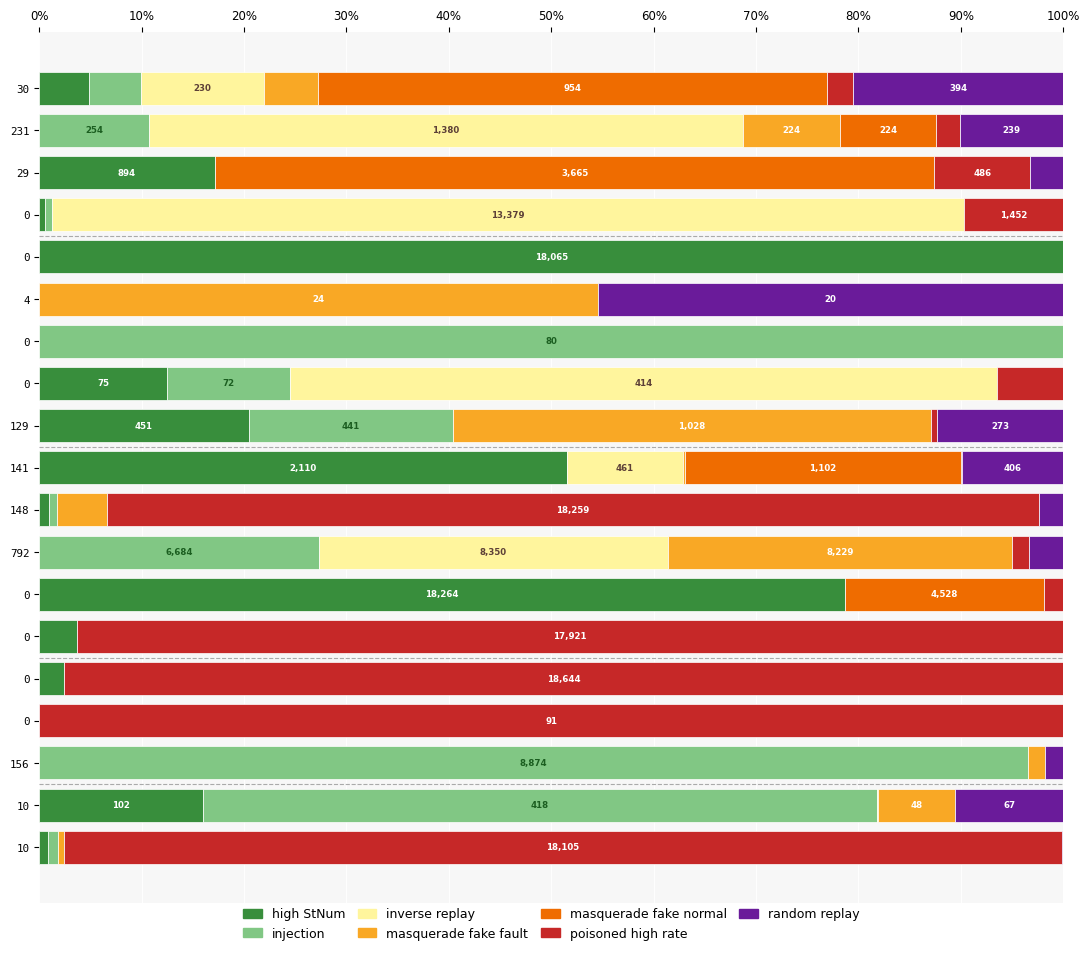

In [11]:
import copy
import matplotlib.path as mpath

def _patched_deepcopy(self, memo):
    cls = self.__class__
    result = cls.__new__(cls)
    memo[id(self)] = result
    for k, v in self.__dict__.items():
        setattr(result, k, copy.deepcopy(v, memo))
    result._readonly = False
    return result

mpath.Path.__deepcopy__ = _patched_deepcopy
# ─────────────────────────────────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
import shutil
from datetime import datetime

# ── IMPORTANTE: Configuração para o notebook ────────────────────
# Verifica se está em um notebook e configura o backend
try:
    from IPython import get_ipython
    if get_ipython() is not None:
        get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass
# ─────────────────────────────────────────────────────────────────

# ── Ajuste o caminho do CSV aqui ────────────────────────────────
CSV_PATH = "matriz_regras_ataques.csv"
OUTPUT   = "matriz_regras_ataques_plot.png"
# ────────────────────────────────────────────────────────────────

# ── Lê o CSV ───────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

print("Colunas encontradas:", df.columns.tolist())
print("\nTipos das colunas:")
print(df.dtypes)
print("\nPrimeiras 3 linhas:")
print(df.head(3))

# Encontra a coluna que contém os nomes das regras
rule_col = None
for col in df.columns:
    if df[col].dtype == 'object':
        sample_values = df[col].dropna().astype(str).head(5)
        if any('rule_' in str(v).lower() for v in sample_values):
            rule_col = col
            break

if rule_col is None:
    for col in df.columns:
        if df[col].dtype == 'object':
            rule_col = col
            break

if rule_col is None:
    rule_col = df.columns[0]

print(f"\n Coluna de regras identificada: '{rule_col}'")

df = df.set_index(rule_col)
df.index = df.index.astype(str)

print(f" Dimensões: {df.shape[0]} regras × {df.shape[1]} classes")
print(f" Primeiros índices: {df.index[:5].tolist()}")

df = df.drop(columns=["normal"], errors="ignore")
df = df[df.sum(axis=1) > 0]

if df.empty:
    print(" Nenhuma regra disparou! Verifique os dados.")
else:
    df_pct = df.div(df.sum(axis=1), axis=0) * 100

    # ── Paleta de cores ──────────────────────────────────────────
    KNOWN_COLORS = {
        "grayhole":               "#1b5e20",
        "high_StNum":             "#388e3c",
        "injection":              "#81c784",
        "inverse_replay":         "#fff59d",
        "masquerade_fake_fault":  "#f9a825",
        "masquerade_fake_normal": "#ef6c00",
        "poisoned_high_rate":     "#c62828",
        "random_replay":          "#6a1b9a",
    }

    KNOWN_TEXT = {
        "grayhole":               "white",
        "high_StNum":             "white",
        "injection":              "#1b5e20",
        "inverse_replay":         "#5d4037",
        "masquerade_fake_fault":  "white",
        "masquerade_fake_normal": "white",
        "poisoned_high_rate":     "white",
        "random_replay":          "white",
    }

    _FALLBACK_PALETTE = plt.cm.tab20.colors
    attacks = df_pct.columns.tolist()

    def _luminance(hex_color):
        c = hex_color.lstrip("#")
        r, g, b = (int(c[i:i+2], 16) / 255 for i in (0, 2, 4))
        def lin(v): return v / 12.92 if v <= 0.04045 else ((v + 0.055) / 1.055) ** 2.4
        return 0.2126 * lin(r) + 0.7152 * lin(g) + 0.0722 * lin(b)

    attack_colors = {}
    text_color_map = {}
    _fallback_idx = 0
    for atk in attacks:
        if atk in KNOWN_COLORS:
            attack_colors[atk] = KNOWN_COLORS[atk]
            text_color_map[atk] = KNOWN_TEXT[atk]
        else:
            color = "#{:02x}{:02x}{:02x}".format(
                *[int(c * 255) for c in _FALLBACK_PALETTE[_fallback_idx % 20][:3]]
            )
            attack_colors[atk] = color
            text_color_map[atk] = "white" if _luminance(color) < 0.4 else "#333333"
            _fallback_idx += 1

    # ── Plot ─────────────────────────────────────────────────────
    rules      = df_pct.index.tolist()
    n_rules    = len(rules)
    fig_height = max(10, n_rules * 0.48)

    fig, ax = plt.subplots(figsize=(11, fig_height))
    
    rule_labels = [str(r).replace("rule_", "") for r in rules]

    lefts = np.zeros(n_rules)
    for attack in attacks:
        color    = attack_colors[attack]
        txt_col  = text_color_map[attack]
        pct_vals = df_pct[attack].values
        abs_vals = df[attack].values
        ax.barh(
            range(n_rules), pct_vals, left=lefts,
            color=color, edgecolor="white", linewidth=0.5, height=0.78
        )
        for j, (pct, abv, l) in enumerate(zip(pct_vals, abs_vals, lefts)):
            if pct >= 7:
                ax.text(
                    l + pct / 2, j, f"{int(abv):,}",
                    ha="center", va="center",
                    fontsize=6.2, color=txt_col, fontweight="bold"
                )
        lefts += pct_vals

    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 10))
    ax.set_xticklabels([f"{x}%" for x in range(0, 101, 10)], fontsize=8.5)
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.tick_params(axis="x", bottom=False, top=True, labelbottom=False, labeltop=True)

    ax.set_yticks(range(n_rules))
    ax.set_yticklabels(rule_labels, fontsize=7.8, fontfamily="monospace")
    ax.invert_yaxis()

    separators = [3.5, 8.5, 13.5, 16.5, 21.5, 25.5, 28.5]
    for s in separators:
        if s < n_rules:
            ax.axhline(s, color="#aaaaaa", linewidth=0.8, linestyle="--", zorder=2)

    ax.set_axisbelow(True)
    ax.xaxis.grid(True, color="white", linewidth=0.7)
    ax.set_facecolor("#f7f7f7")
    for spine in ax.spines.values():
        spine.set_visible(False)

    patches = [
        mpatches.Patch(color=attack_colors[a], label=a.replace("_", " "))
        for a in attacks
    ]
    ax.legend(
        handles=patches,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.055),
        ncol=4, fontsize=9,
        frameon=False,
        handlelength=1.5,
        columnspacing=1.0
    )

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    
    # ── Backup do gráfico anterior ────────────────────────────────
    old_charts_dir = "old_charts"
    os.makedirs(old_charts_dir, exist_ok=True)

    if os.path.exists(OUTPUT):
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        nome_backup = os.path.join(old_charts_dir, f"matriz_regras_ataques_plot_{timestamp}.png")
        shutil.copy2(OUTPUT, nome_backup)
        print(f" Backup salvo em: {nome_backup}")
    # ─────────────────────────────────────────────────────────────

    # Salva a figura
    plt.savefig(OUTPUT, dpi=100, bbox_inches="tight")
    print(f" Salvo em: {OUTPUT}")
    
    # Mostra a figura (agora vai funcionar com %matplotlib inline)
    plt.show()

---
## 9. Considerações Finais

Este trabalho apresentou um pipeline orientado por LLM que automatiza a geração de regras de detecção para IDS baseados em especificação em subestações IEC 61850.

### Contribuições principais

- **Pipeline plug-and-play** end-to-end: do dataset rotulado às regras executáveis
- **Redução da dependência de especialistas** para criação manual de regras
- **Baixo overhead operacional**: regras Python leves adequadas a ambientes em tempo real
- **Reprodutibilidade**: parâmetros configuráveis e artefatos rastreáveis

### Limitações e trabalhos futuros

- Validação em hardware real de subestação (não apenas simulado)
- Avaliação com mais classes de ataque do dataset ERENO
- Comparação com abordagens de ML supervisionado
- Adaptação automática a novos padrões de ataque via atualização incremental

> **Repositório:** https://github.com/sequincozes/CounselorNode

---
## 10. Referências

- **Commission, I. E.** (2003). Communication networks and systems in substations - Part 8-1: SCSM. IET.

- **Hong, J. and Liu, C.** (2019). Intelligent electronic devices with collaborative intrusion detection systems. *IEEE Transactions on Smart Grid*, 10(1):271–281.

- **Hong, J., Liu, C., and Govindarasu, M.** (2014a). Detection of Cyber Intrusions Using Network-Based Multicast Messages for Substation Automation. *ISGT*, IEEE.

- **Hong, J., Liu, C., and Govindarasu, M.** (2014b). Integrated anomaly detection for cyber security of the substations. *IEEE Transactions on Smart Grid*, 5(4):1643–1653.

- **Kwon, Y. et al.** (2015). A behavior-based intrusion detection technique for smart grid infrastructure. *IEEE Eindhoven PowerTech*.

- **Malik, H., Alotaibi, M. A., and Almutairi, A.** (2022). Cyberattacks identification in IEC 61850 based substation using proximal SVM. *Journal of Intelligent & Fuzzy Systems*, 42(2):1213–1222.

- **Quincozes, S. E. et al.** (2021). A survey on intrusion detection and prevention systems in digital substations. *Computer Networks*, 184:107679.

- **Quincozes, S. E. et al.** (2022). ERENO: An Extensible Tool for Generating Realistic IEC–61850 Intrusion Detection Datasets. PhD thesis, UFF.

- **Yang, Y. et al.** (2016a). Intrusion detection system for IEC 61850 based smart substations. *IEEE PESGM*.

- **Yang, Y. et al.** (2016b). Multidimensional intrusion detection system for IEC 61850-based SCADA networks. *IEEE Transactions on Power Delivery*, 32(2):1068–1078.